In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import gsw
from sklearn.mixture import GaussianMixture
from funcs import cross_sec_lon, cross_sec_lon_prob, cross_sec_lon_prob2, calc_pv, method34

In [2]:
# Get data into dataframe
df = pd.read_csv('../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to contain the relevant features
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]','Profile_Number']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month','Profile_Number']]

# Calculate potential vorticity
df_ST = calc_pv(df_ST)

In [3]:
df_ST.head()

,Conservative_Temperature_[deg_C],Absolute_Salinity_[PSU],Dissolved_Oxygen_[micro_mol_per_kg],Depth_[m],Latitude_[deg_N],Longitude_[deg_E],year,month,Profile_Number,Pv
0,9.222,35.352,NaN,15.0,63.315,-0.075,2009,8,1,1.572741e-08
1,7.958,35.402,NaN,105.0,63.317,-0.017,2009,8,1,-2.711059e-10
2,7.831,35.402,NaN,115.0,63.318,-0.090,2009,8,1,-2.050461e-10
3,7.724,35.400,NaN,125.0,63.309,-0.068,2009,8,1,-3.112159e-10
4,7.550,35.395,NaN,135.0,63.368,-0.018,2009,8,1,-3.764021e-11


In [4]:
# Define random master seed for reproducibility
master_seed = 22
random.seed(master_seed)

# Define a list of random seeds
seeds = random.sample(range(1, 10000), 10)

In [5]:
# Define features to use for clustering
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]','Pv']

In [6]:
df_sampled = method34(df=df_ST, seed=master_seed)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:1026: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [159]:
# Run BIC score calculation for different numbers of clusters and for 10 different seeds
# Do BIC and AIC calculation for different number of clusters
all_scores = {}
n_components_range = range(1, 8)
for i,seed in enumerate(seeds[0:5]):
    bic_scores = [] 
    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
        gmm.fit(df_sampled[features])
        bic_scores.append(gmm.bic(df_sampled[features]))

    all_scores[i] = bic_scores

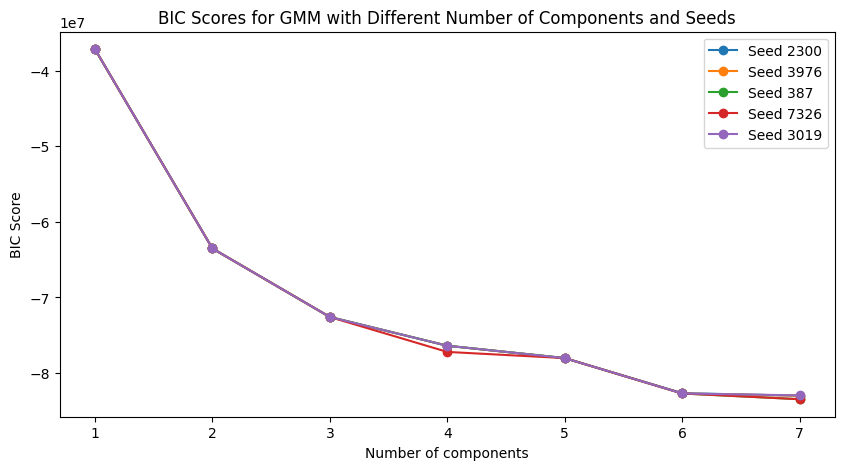

In [162]:
plt.figure(figsize=(10,5))
for i in range(5):
    plt.plot(n_components_range, all_scores[i], label=f'Seed {seeds[i]}', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components and Seeds')
plt.legend()

In [12]:
# Choice of optimal number of clusters based on BIC
n_clusters = 6

In [24]:
gmm_0 = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seeds[0])

labels_0 = gmm_0.fit_predict(df_sampled[features])

In [25]:
gmm_1 = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seeds[1])

labels_1 = gmm_1.fit_predict(df_sampled[features])

In [32]:
df_sampled['gmm_label_6'] = labels_0
df_sampled['gmm_label_6'] = labels_1

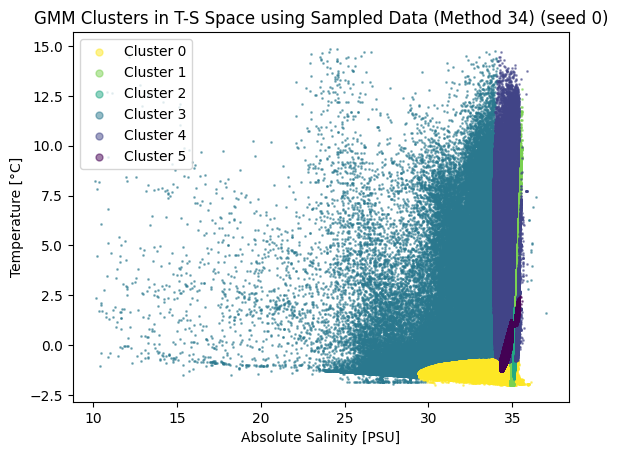

In [30]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_6'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 34) (seed 0)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:625: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



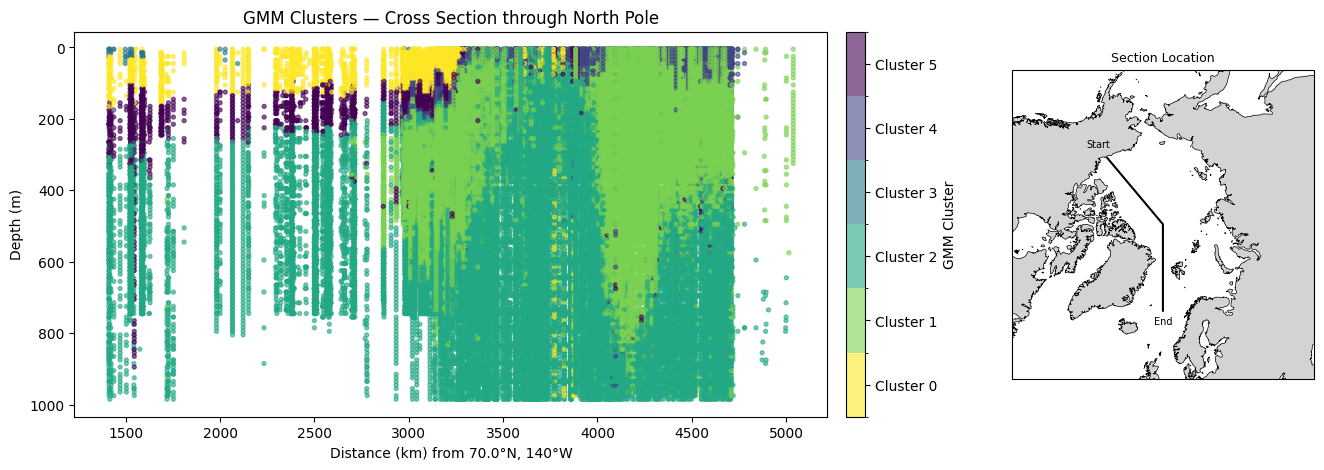

In [31]:
cross_sec_lon(df_sampled, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

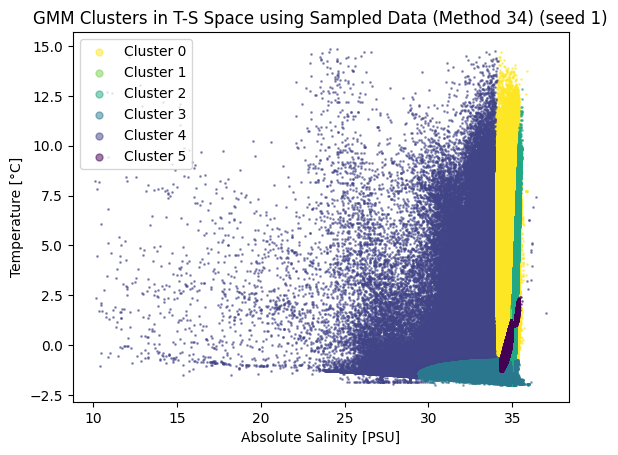

In [33]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_6'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 34) (seed 1)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:625: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



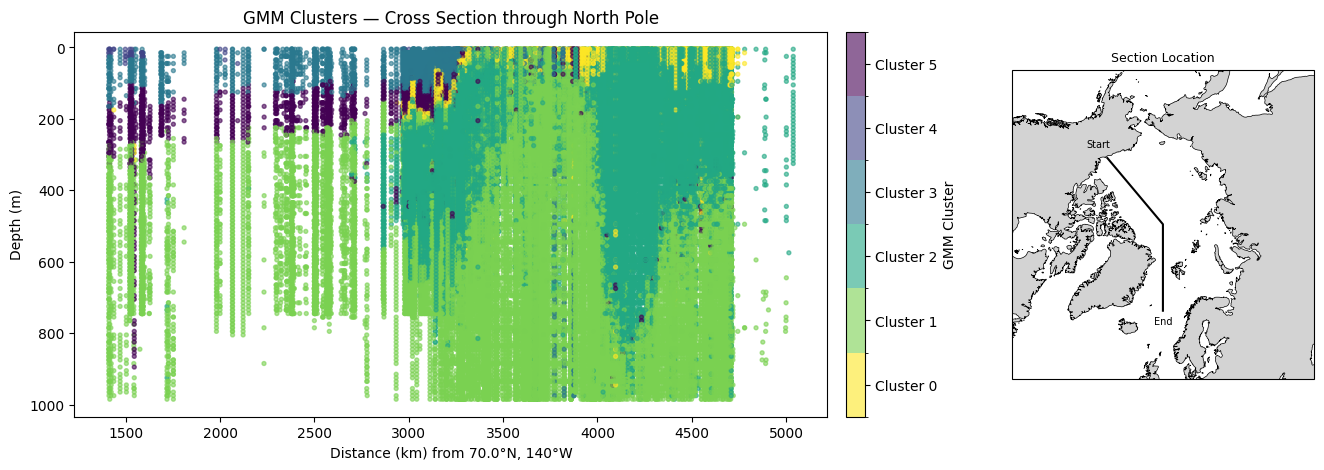

In [34]:
cross_sec_lon(df_sampled, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [139]:
for i in range(n_clusters):
    df_sampled['prob_cluster_'+str(i)] = gmm_0.predict_proba(df_sampled[features])[:, i]

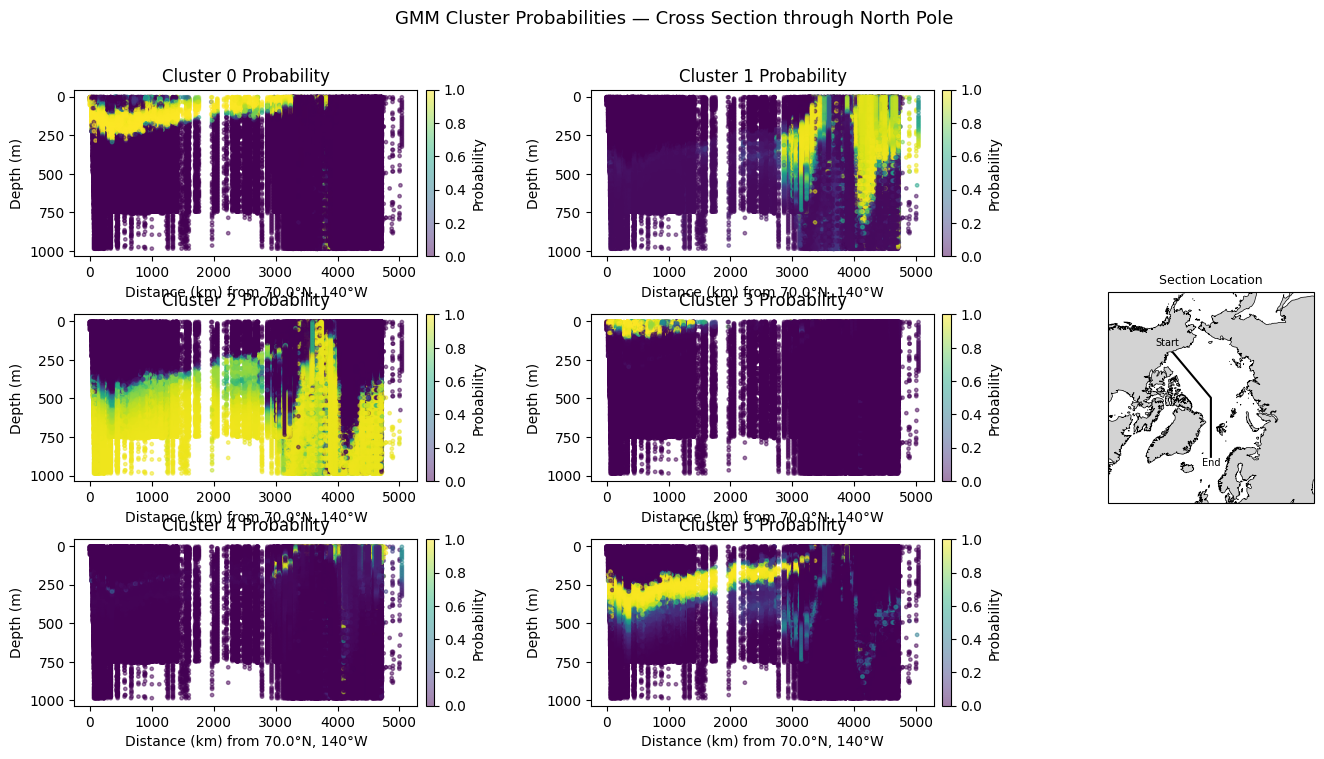

In [252]:
cross_sec_lon_prob(df_sampled,n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_67388/3009811550.py:135: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



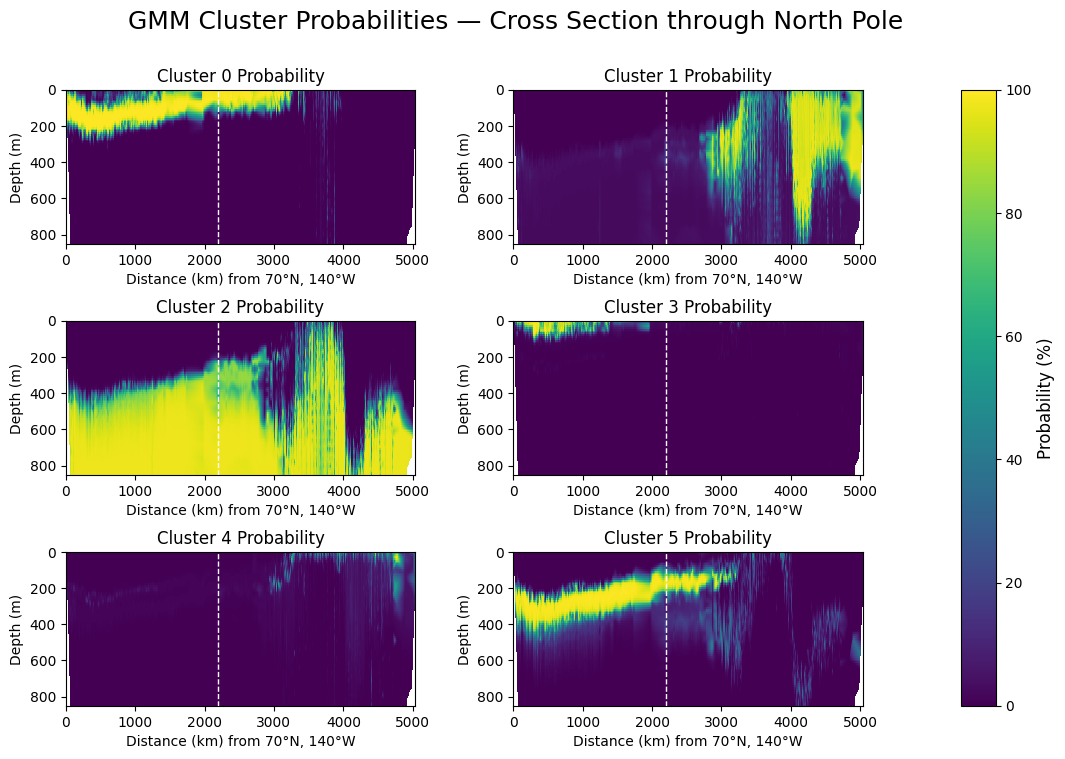

In [250]:
cross_sec_lon_prob2(df_sampled, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [135]:
for i in range(n_clusters):
    df_sampled['prob_cluster_'+str(i)] = gmm_1.predict_proba(df_sampled[features])[:, i]

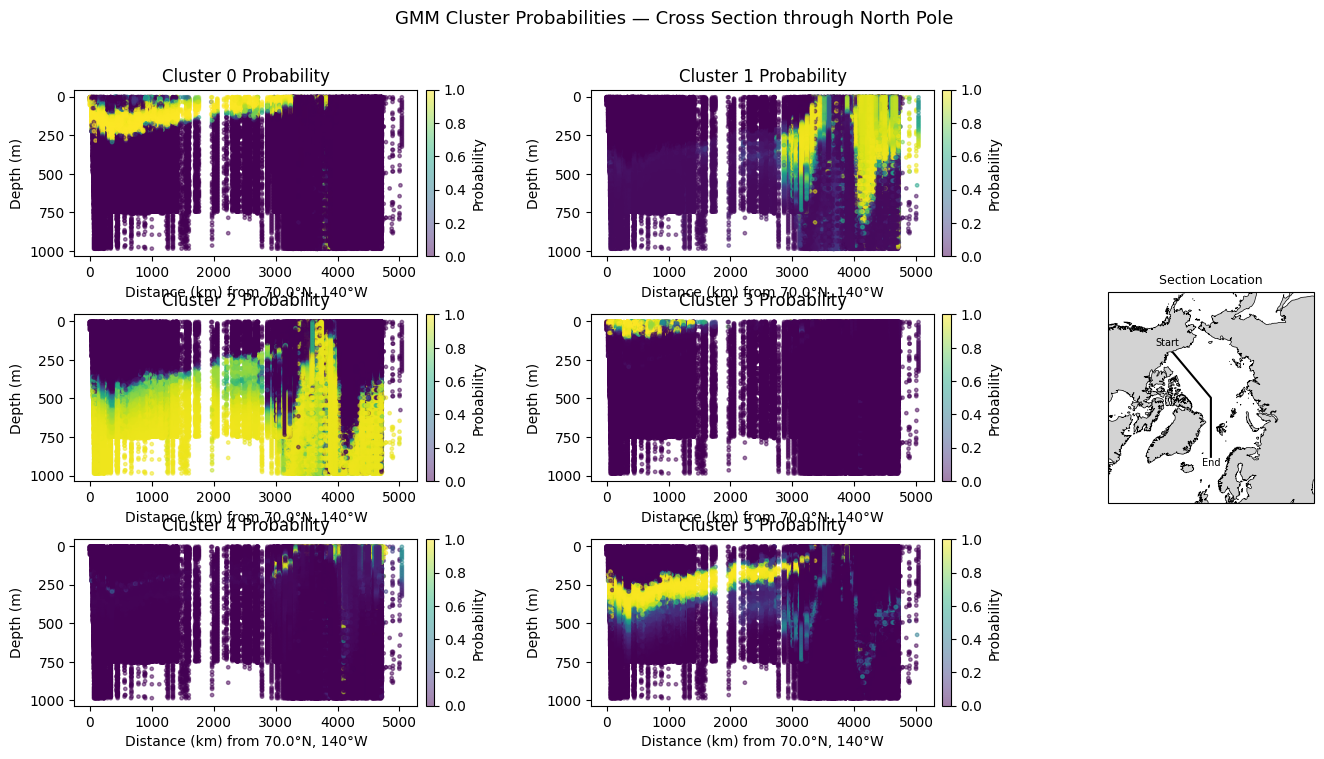

In [238]:
cross_sec_lon_prob(df_sampled, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_67388/2997054114.py:132: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



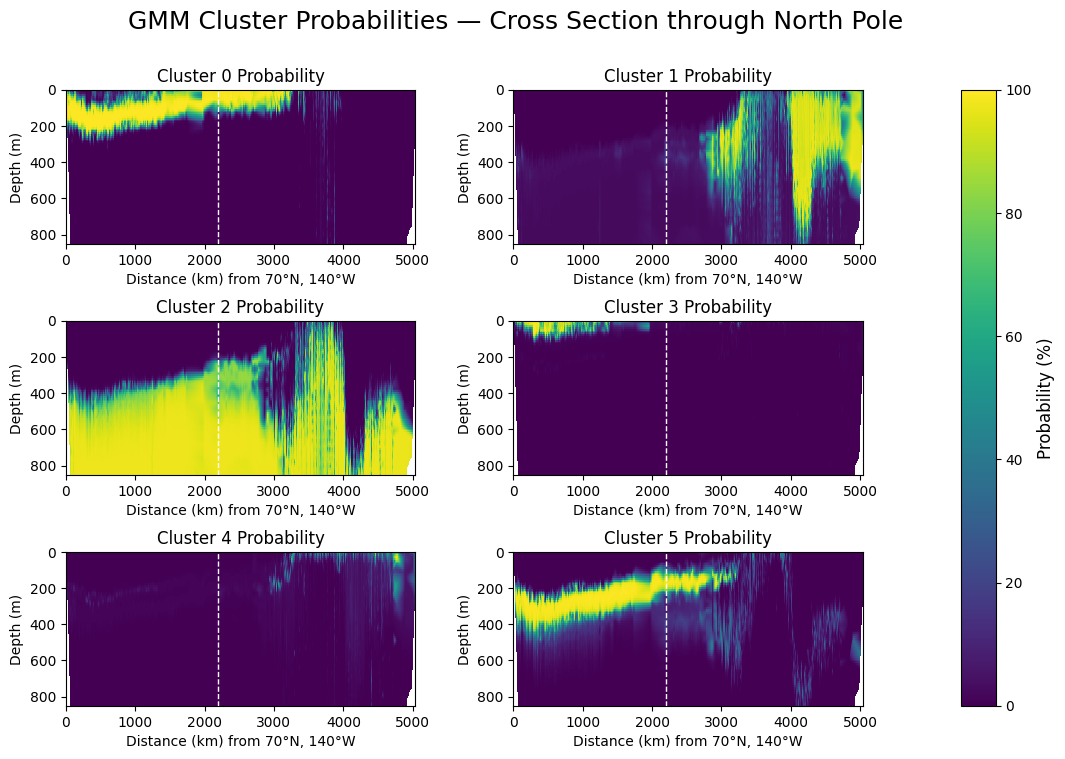

In [239]:
cross_sec_lon_prob2(df_sampled, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140)

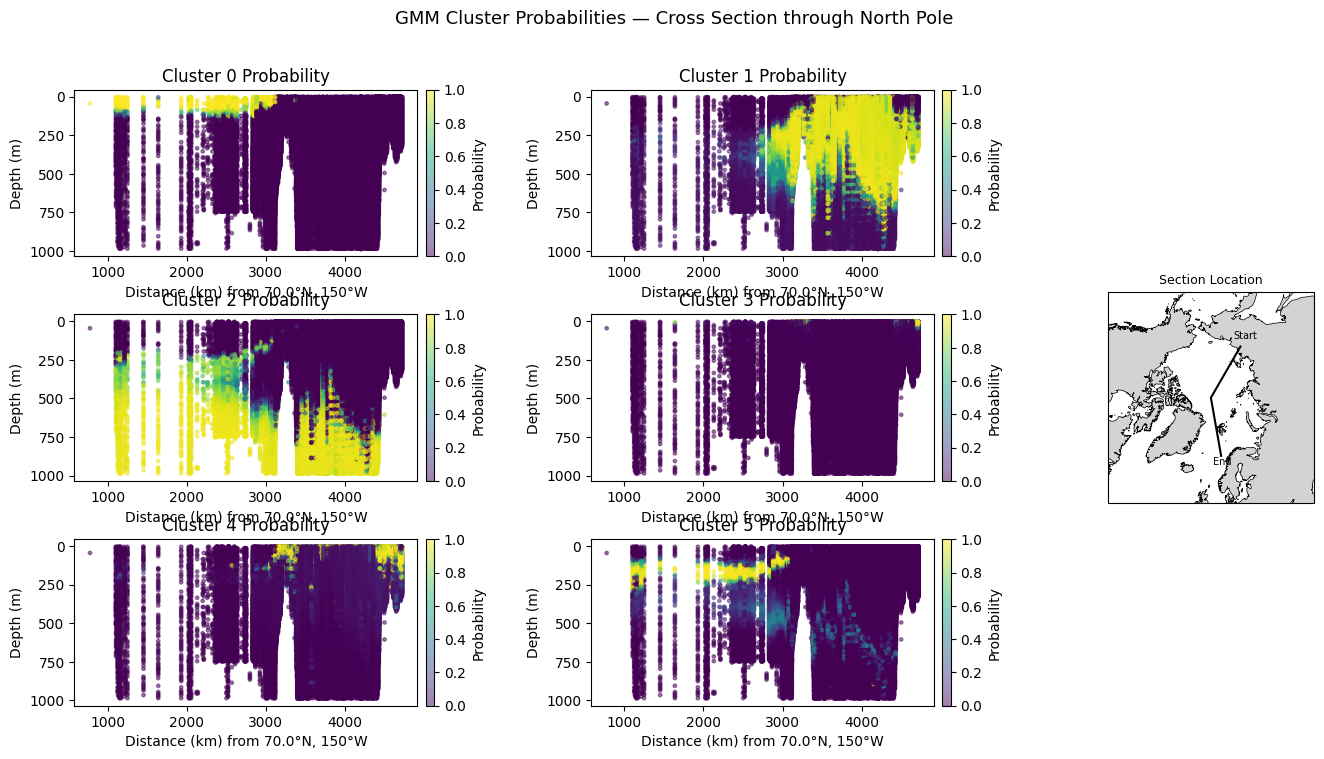

In [251]:
cross_sec_lon_prob(df_sampled, n_clusters, 10, tol=0.5, start_lat=70.0, start_lon=150)

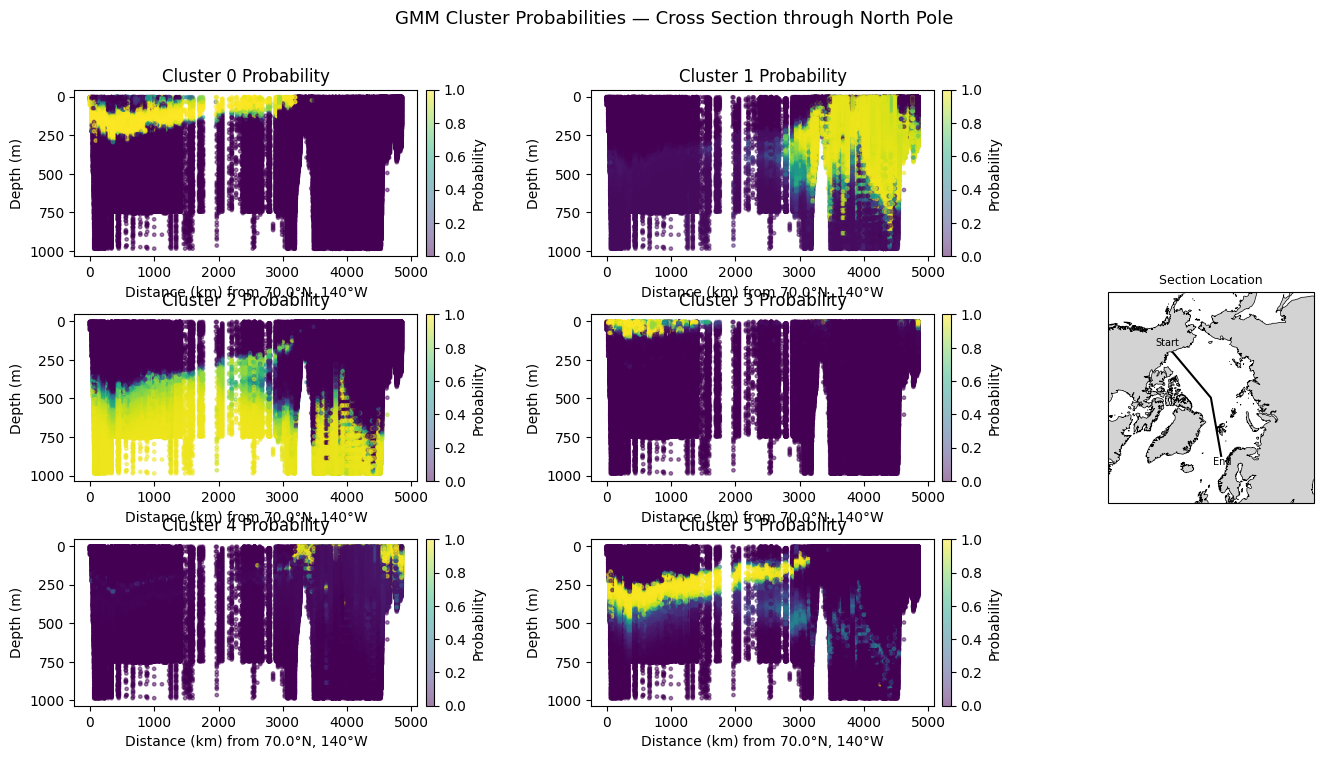

In [246]:
cross_sec_lon_prob(df_sampled, n_clusters, -170, tol=0.5, start_lat=70.0, start_lon=-140)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_67388/3009811550.py:135: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



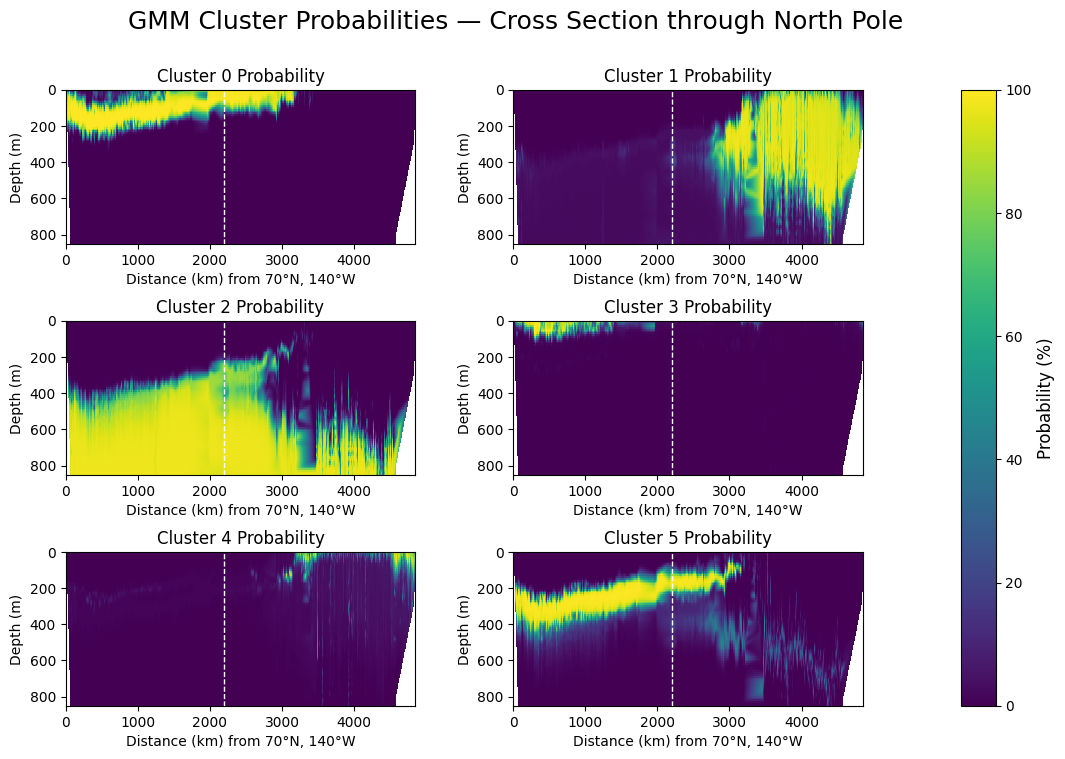

In [249]:
cross_sec_lon_prob2(df_sampled, n_clusters, -170, tol=0.5, start_lat=70.0, start_lon=-140)

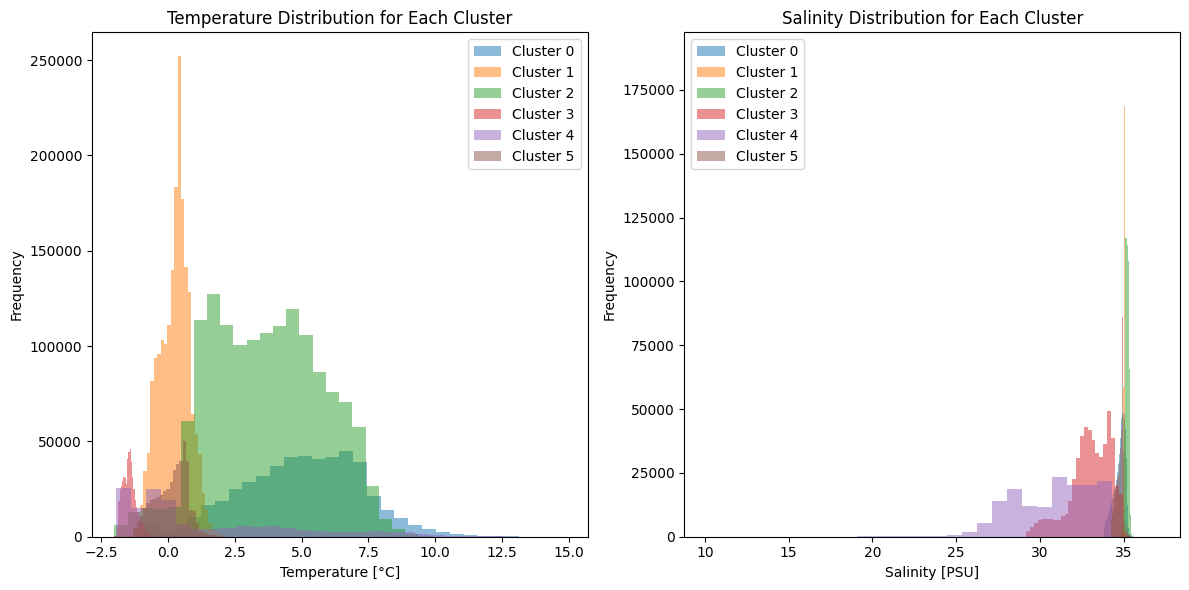

In [253]:
# Diagnostic plots
plt.figure(figsize=(12, 6))

# Temperature distribution for each cluster
plt.subplot(1, 2, 1)
for i in range(n_clusters):
    mask = df_sampled['gmm_label_6'] == i
    plt.hist(df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'], bins=30, alpha=0.5, label=f'Cluster {i}')
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency")
plt.title("Temperature Distribution for Each Cluster")
plt.legend()

# Salinity distribution for each cluster
plt.subplot(1, 2, 2)
for i in range(n_clusters):
    mask = df_sampled['gmm_label_6'] == i
    plt.hist(df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'], bins=30, alpha=0.5, label=f'Cluster {i}')
plt.xlabel("Salinity [PSU]")
plt.ylabel("Frequency")
plt.title("Salinity Distribution for Each Cluster")
plt.legend()

plt.tight_layout()
plt.show()


In [278]:
from matplotlib.ticker import ScalarFormatter

def feature_histograms(df, feat_col='Conservative_Temperature_[deg_C]', label_col='gmm_label_6', feature='Temperature [°C]'):
    n_clusters = df[label_col].nunique()
    colors = plt.cm.viridis(np.linspace(0, 1, n_clusters))

    fig, axes = plt.subplots(n_clusters, 1, figsize=(22, 15), sharex=True)

    if n_clusters == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        cluster_data = df[df[label_col] == i][feat_col]
        ax.hist(cluster_data, bins=50, alpha=0.5, color=colors[i], label=f'Cluster {i}')
        ax.legend()
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    fig.supxlabel(feature)
    fig.supylabel('Frequency', x=0.01)
    fig.suptitle(feature + ' Histograms by GMM Cluster')

    x_min = df[feat_col].min()
    x_max = df[feat_col].max()
    axes[0].set_xlim(x_min, x_max)

    plt.tight_layout()
    plt.show()

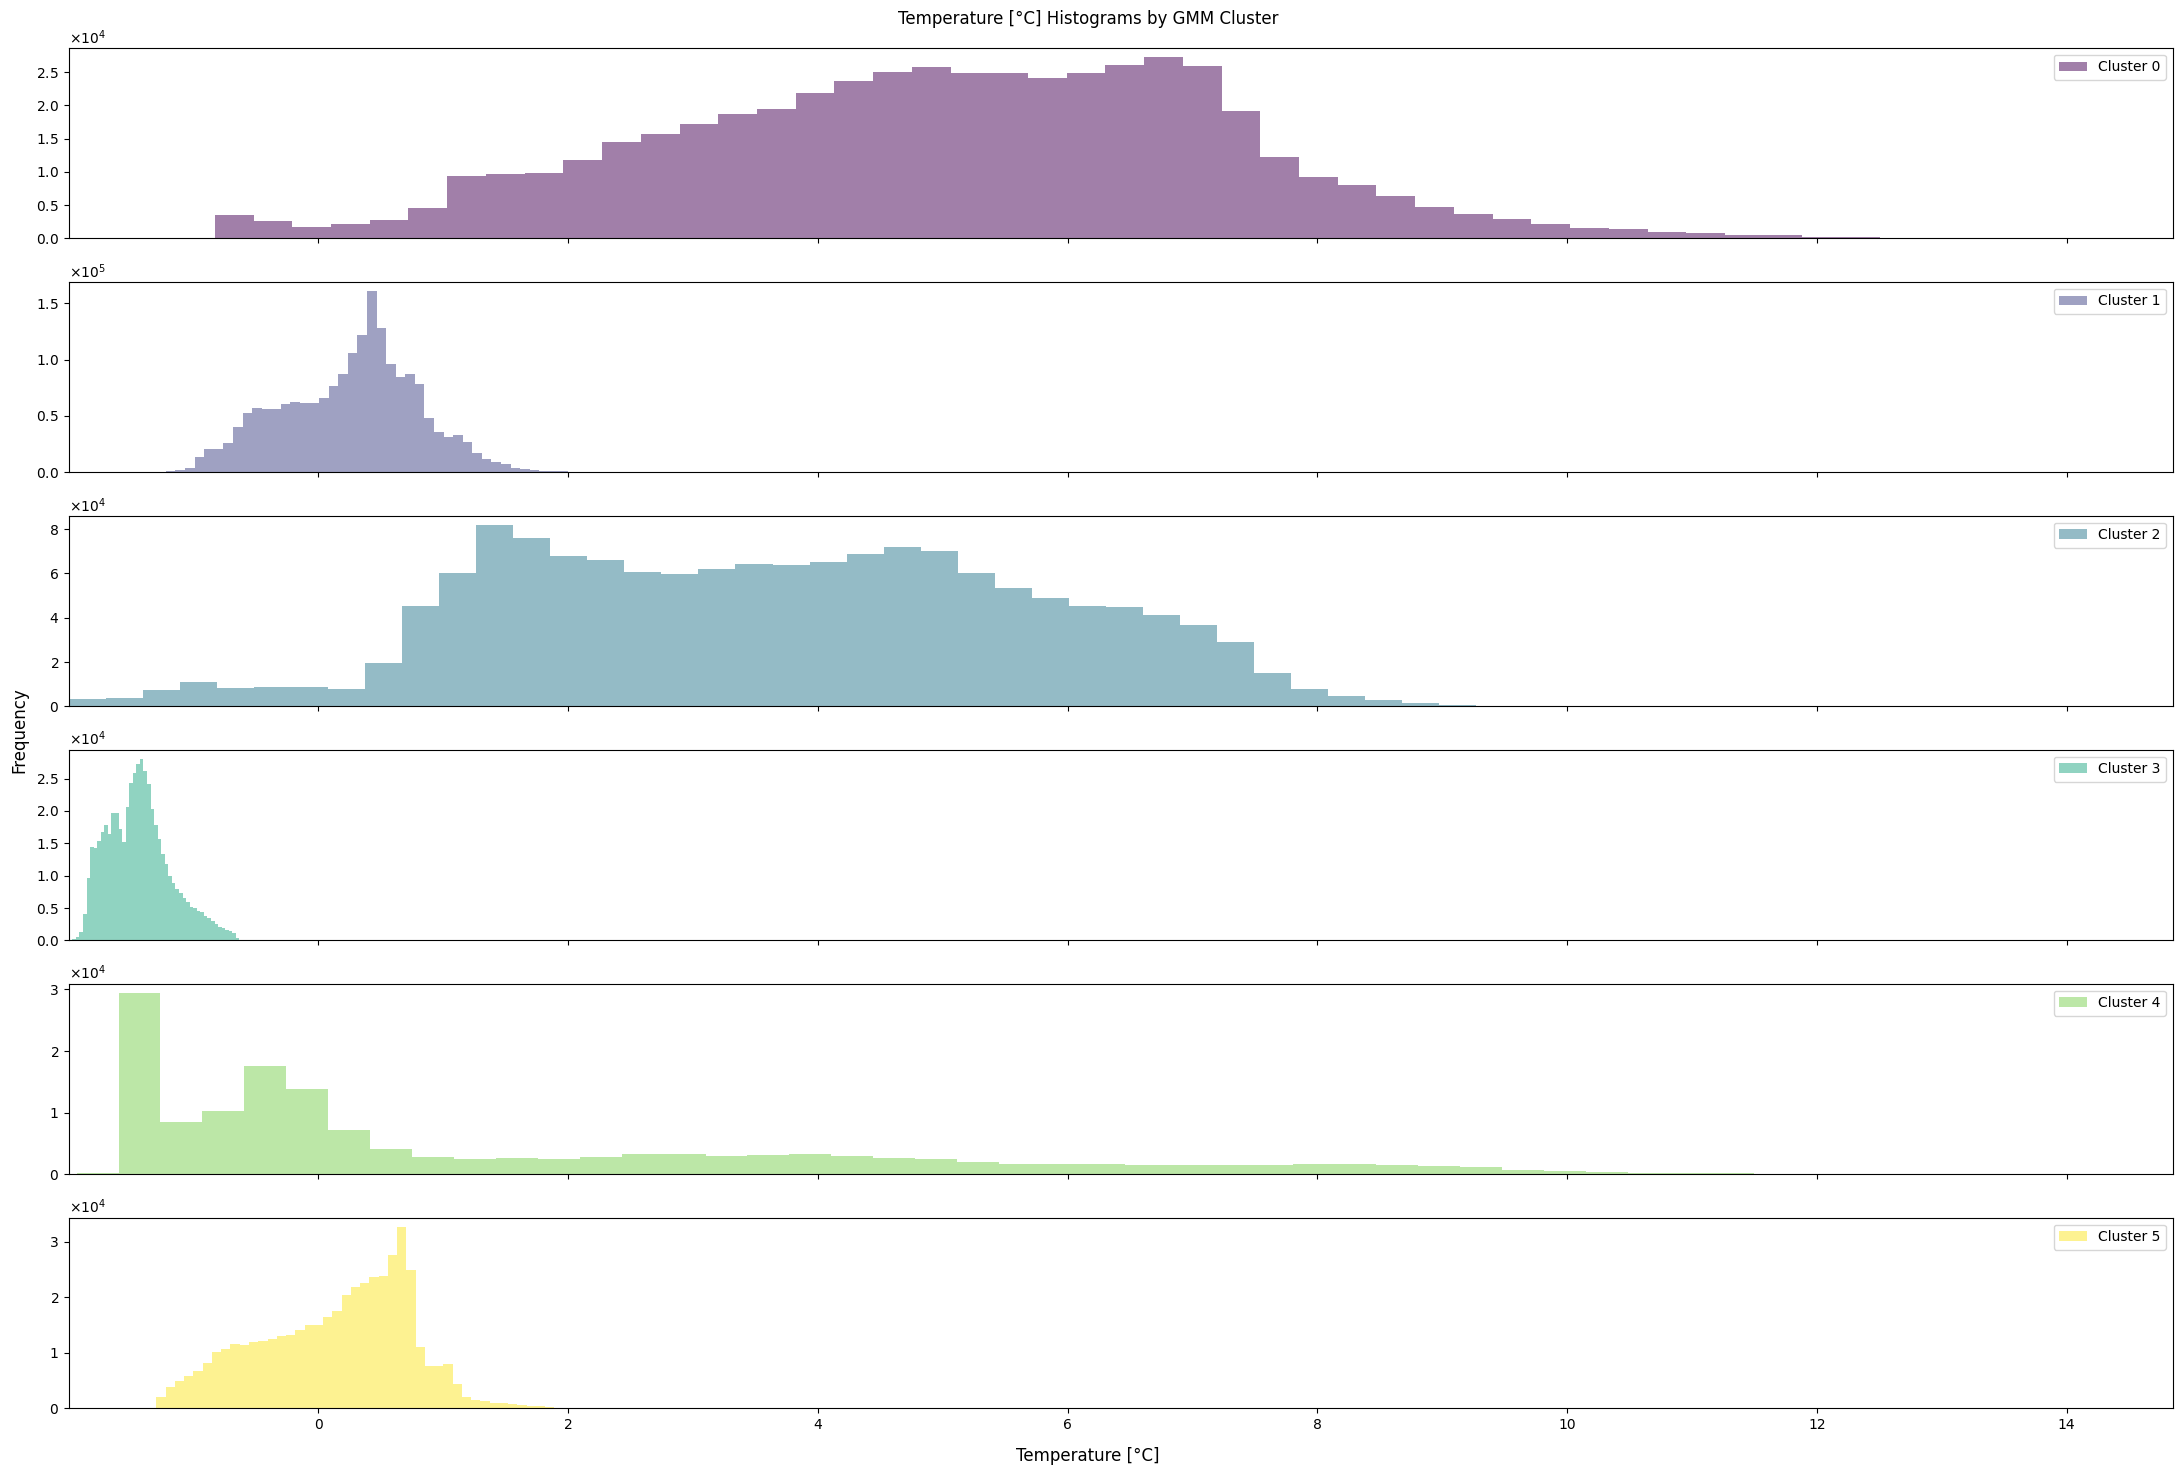

In [279]:
feature_histograms(df_sampled, feat_col='Conservative_Temperature_[deg_C]', label_col='gmm_label_6', feature='Temperature [°C]')

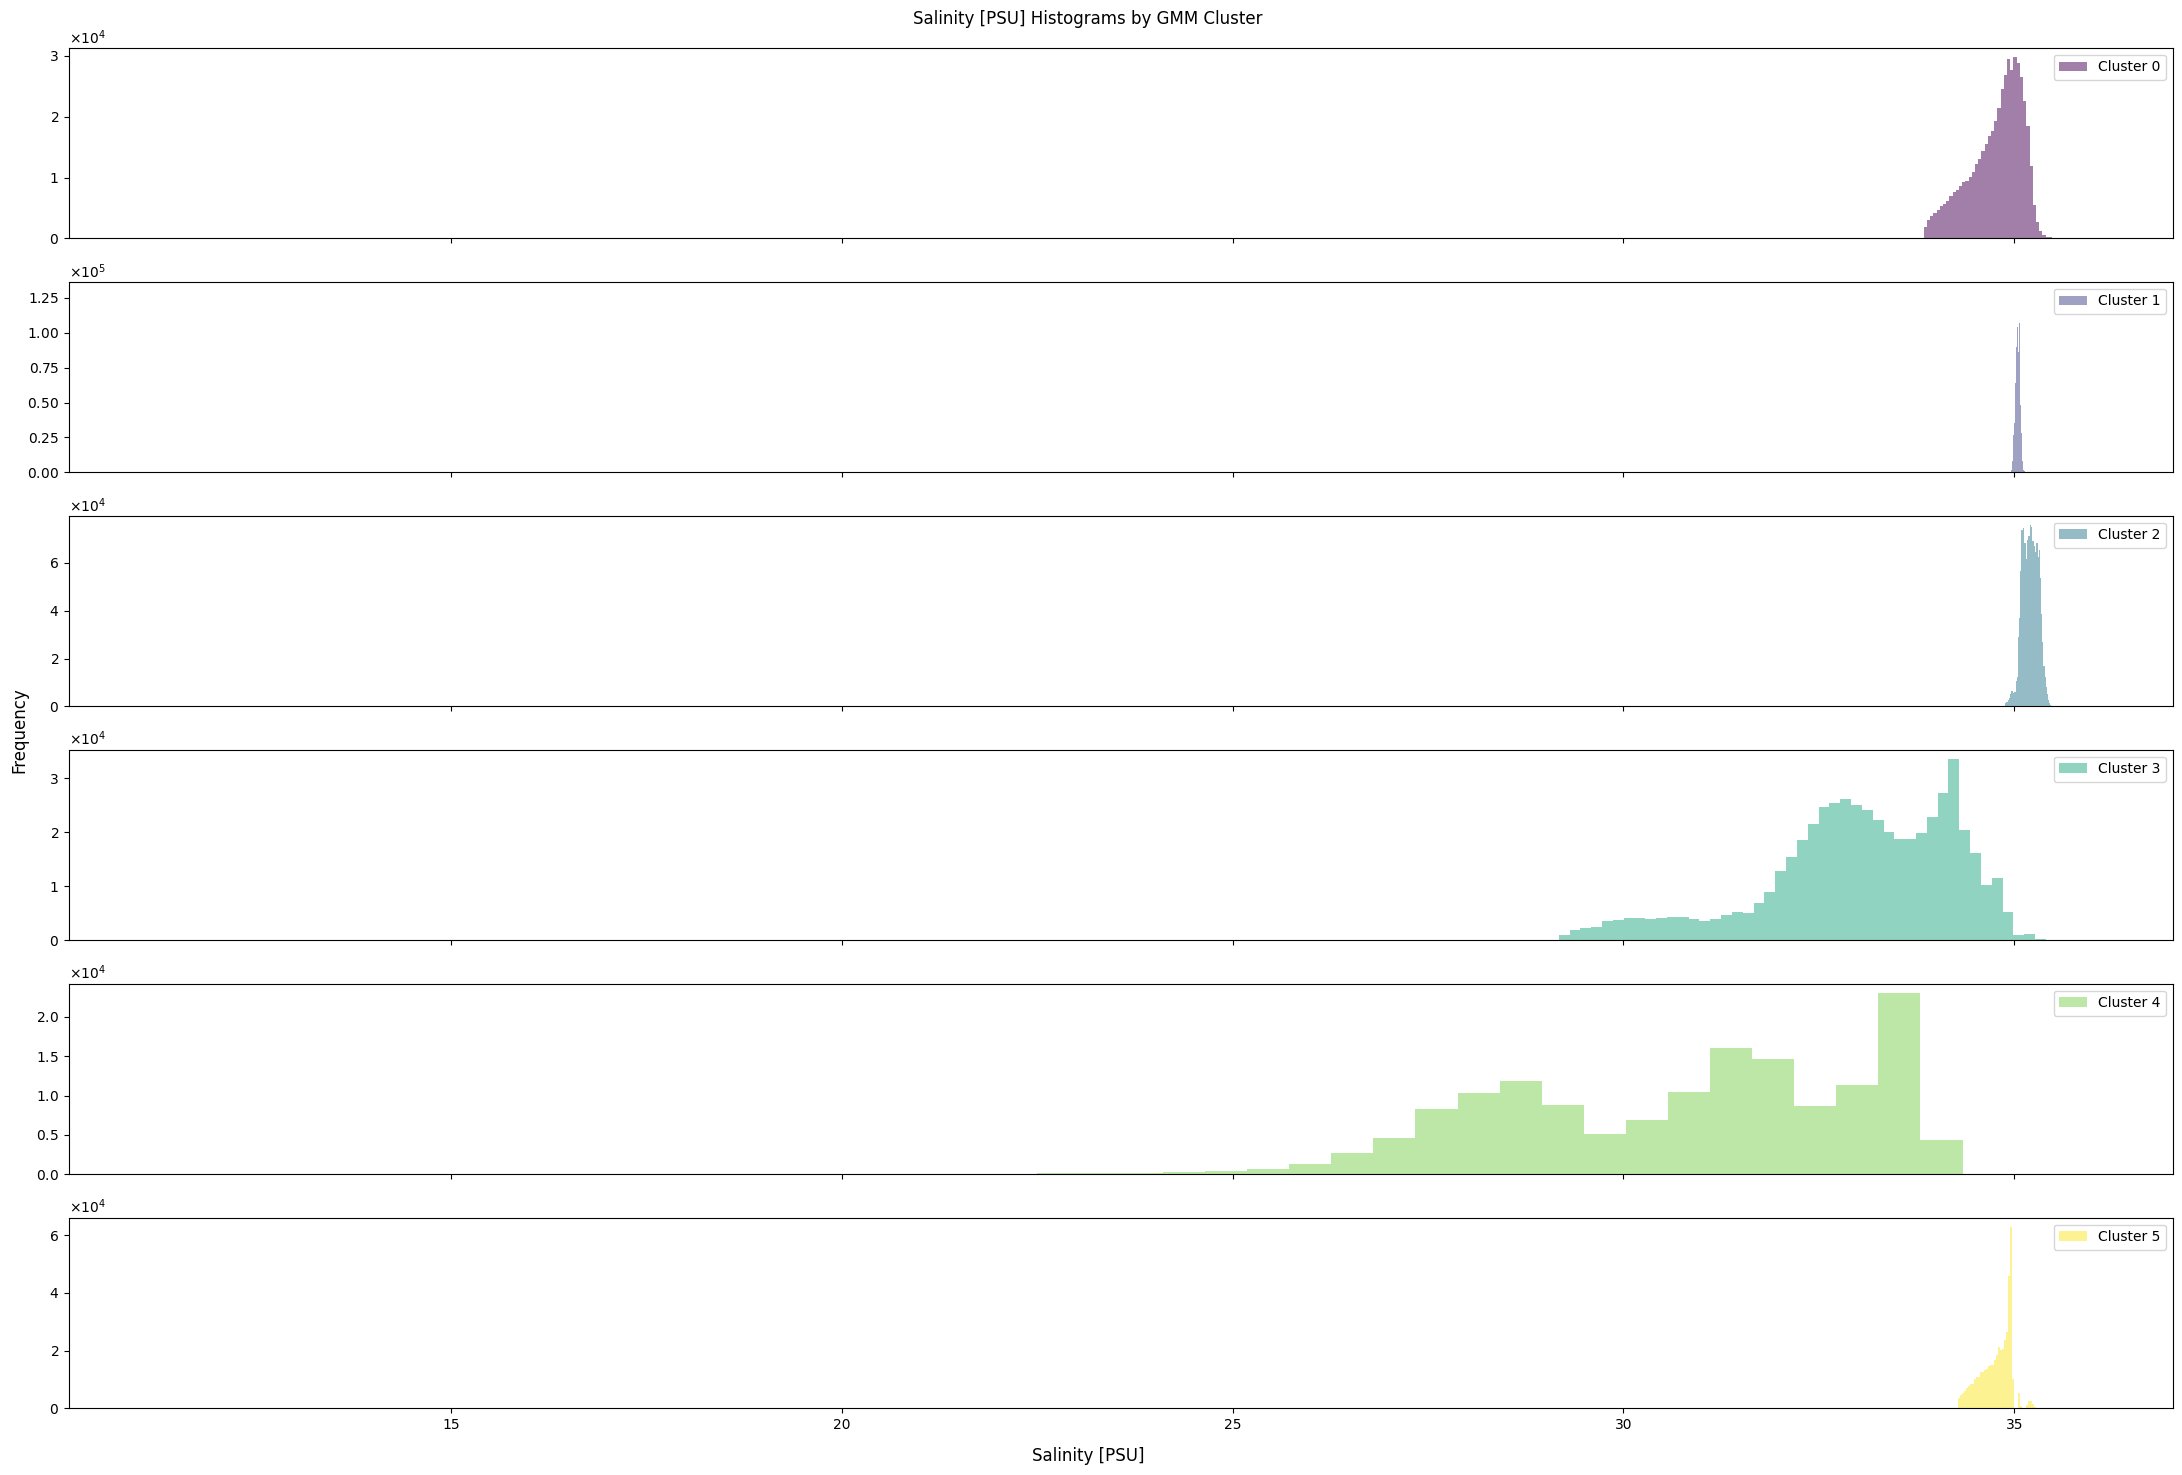

In [280]:
feature_histograms(df_sampled, feat_col='Absolute_Salinity_[PSU]', label_col='gmm_label_6', feature='Salinity [PSU]')

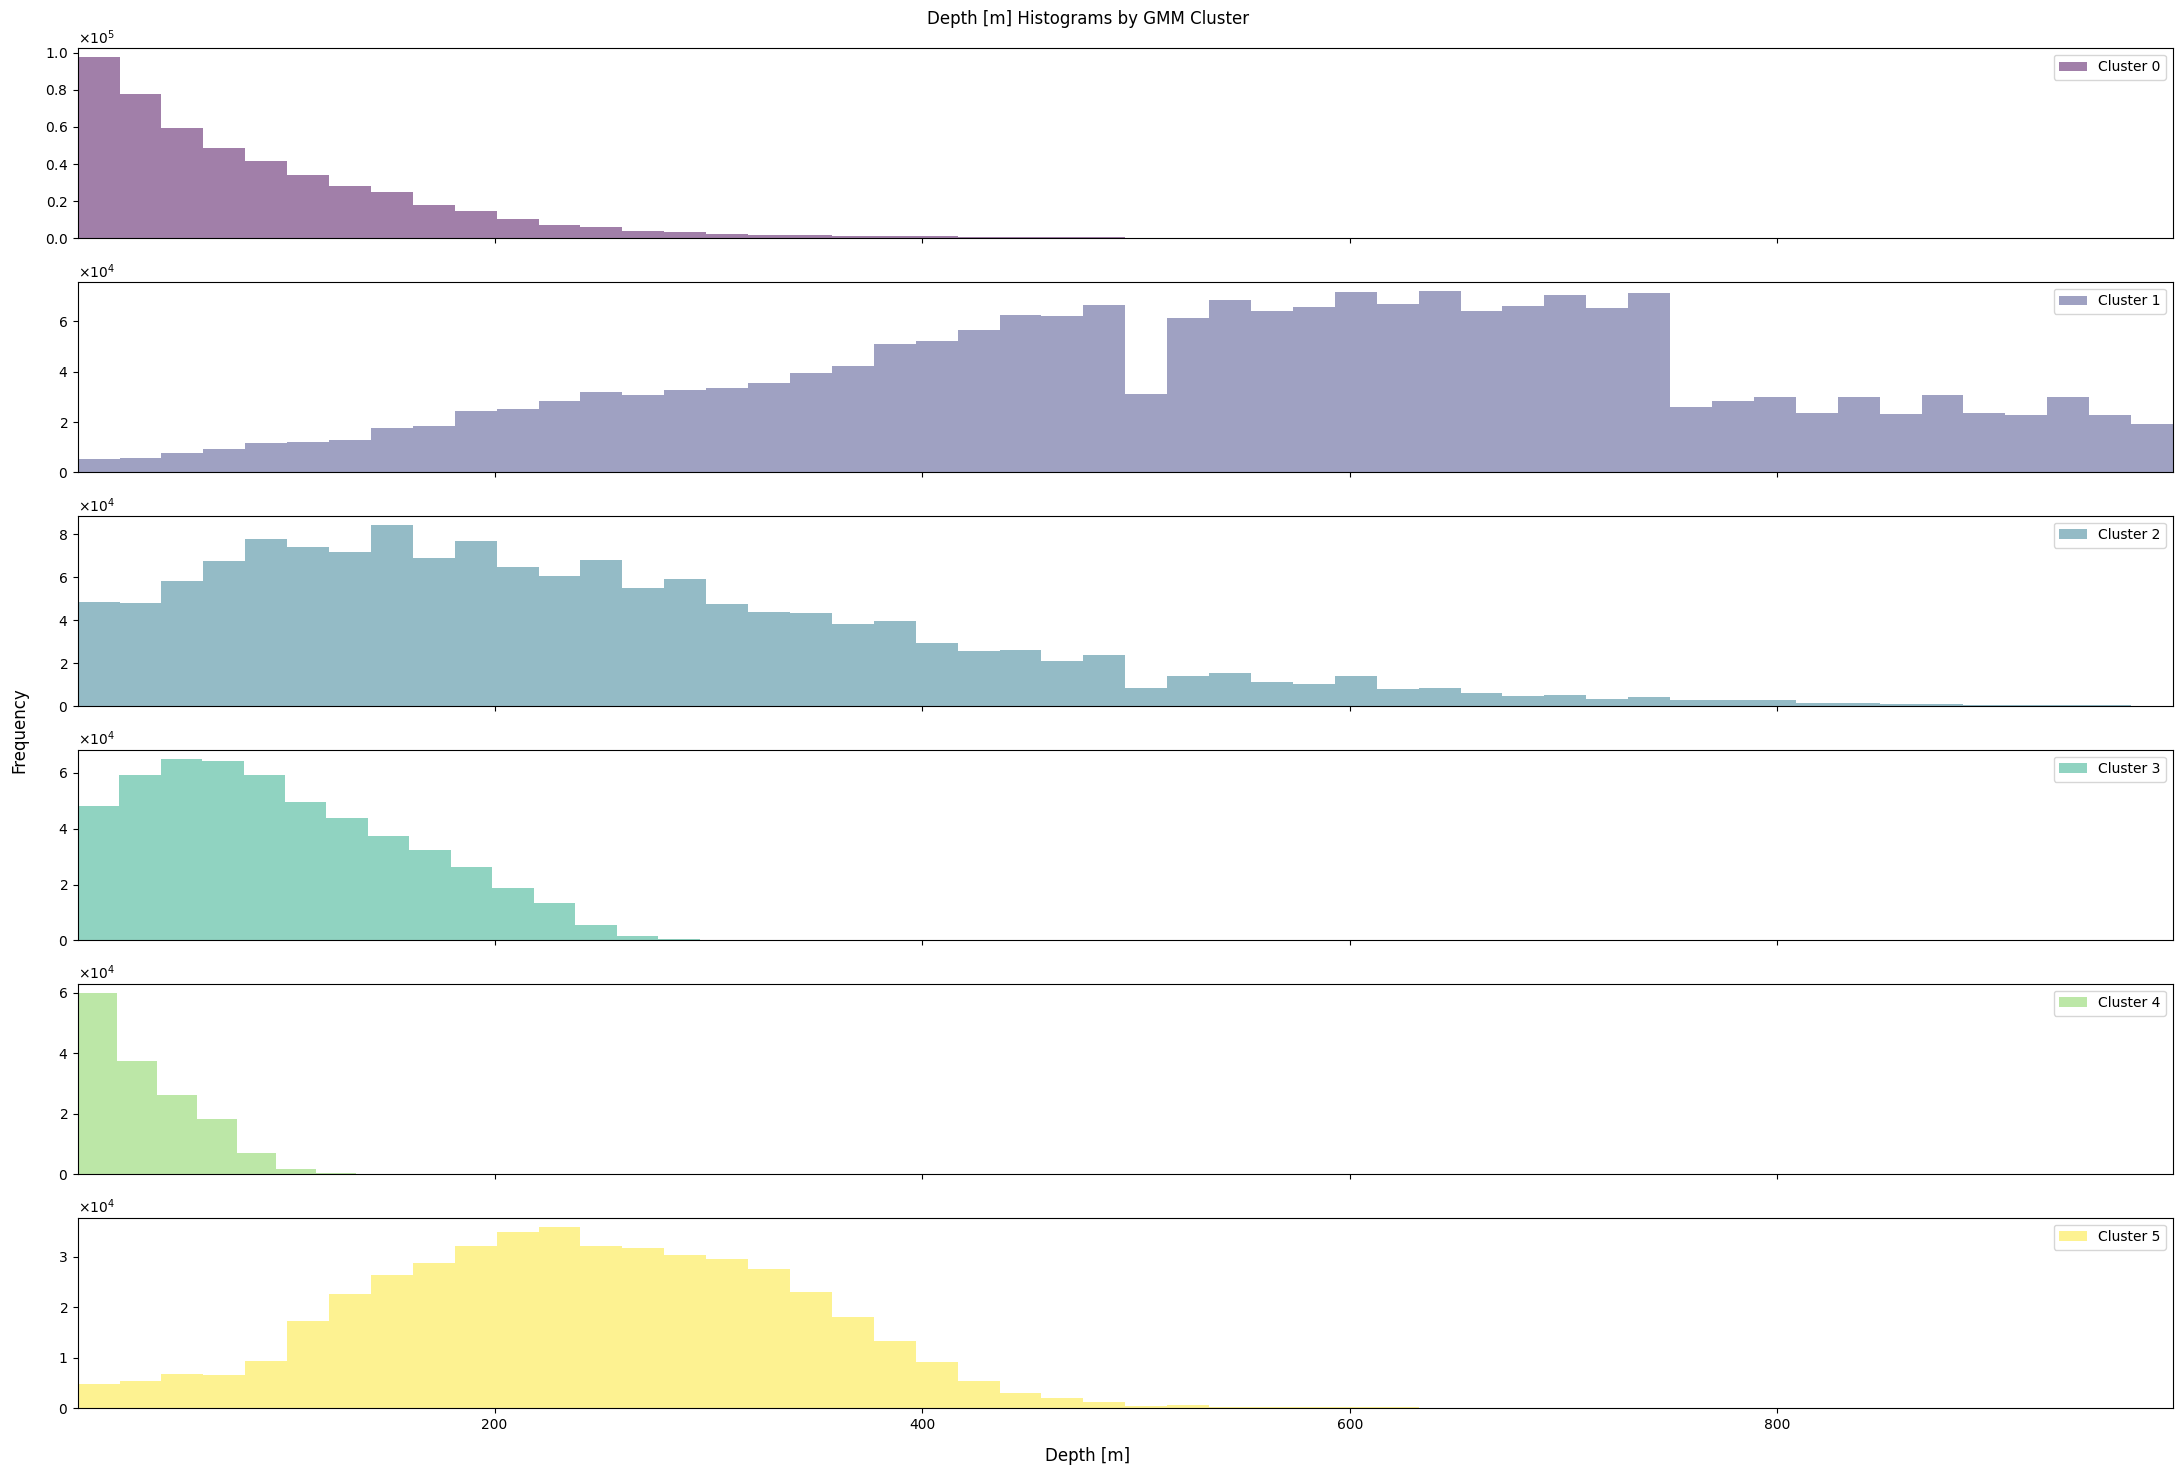

In [281]:
feature_histograms(df_sampled, feat_col='Depth_[m]', label_col='gmm_label_6', feature='Depth [m]')

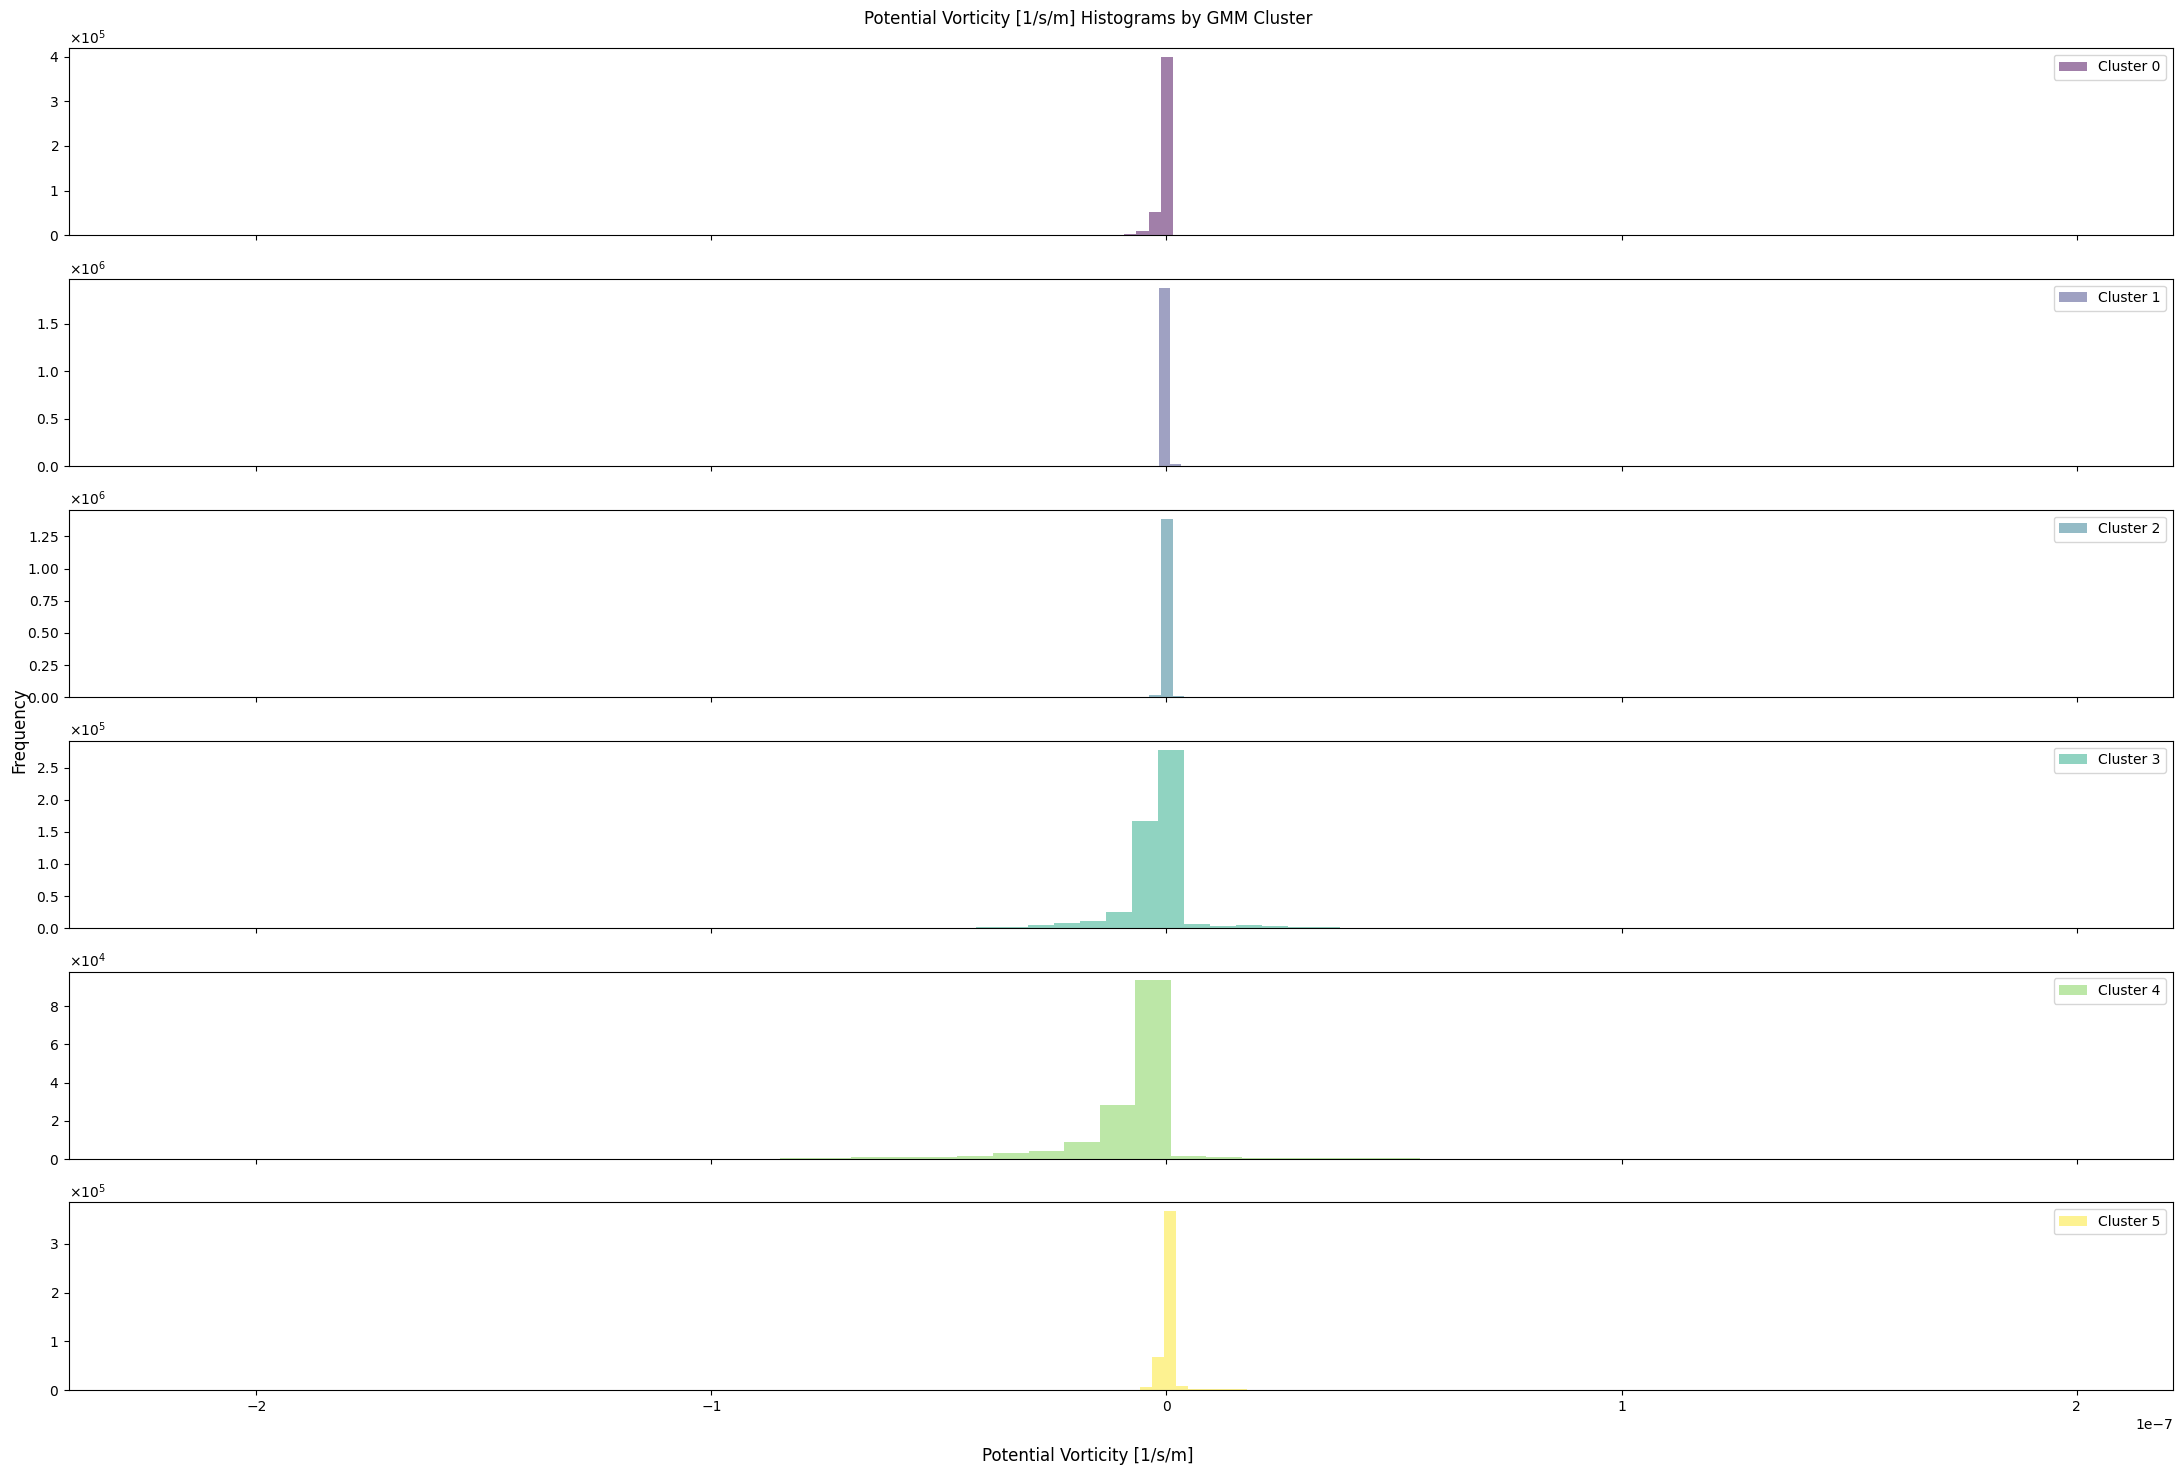

In [282]:
feature_histograms(df_sampled, feat_col='Pv', label_col='gmm_label_6', feature='Potential Vorticity [1/s/m]')

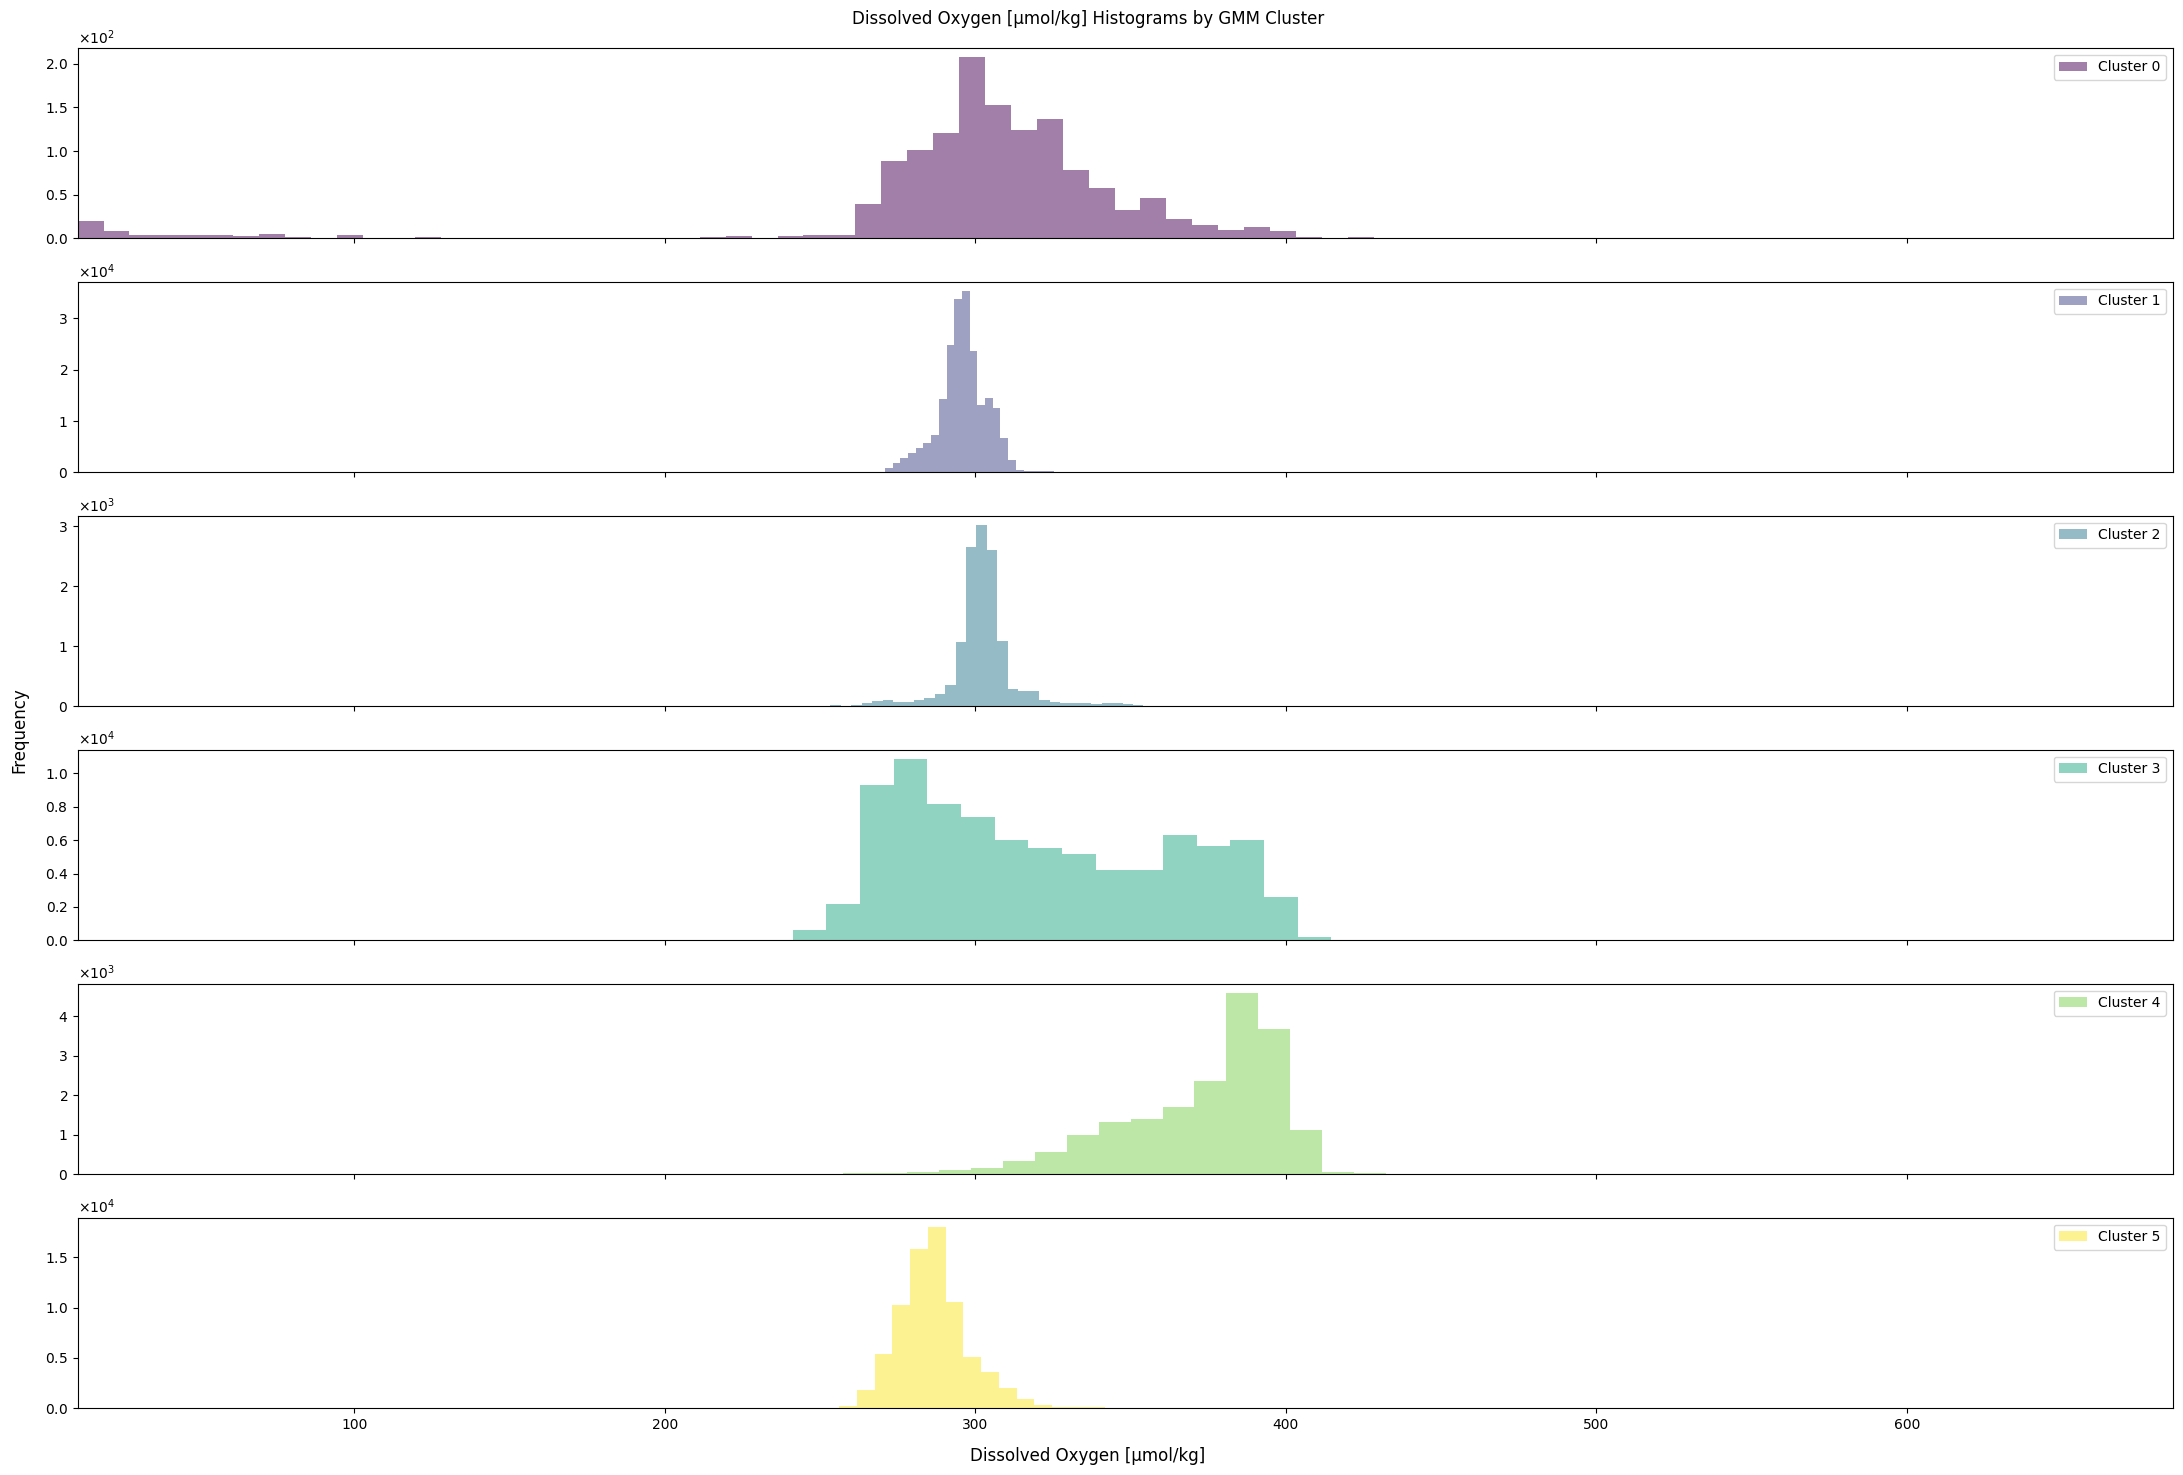

In [283]:
feature_histograms(df_sampled, feat_col='Dissolved_Oxygen_[micro_mol_per_kg]', label_col='gmm_label_6', feature='Dissolved Oxygen [µmol/kg]')

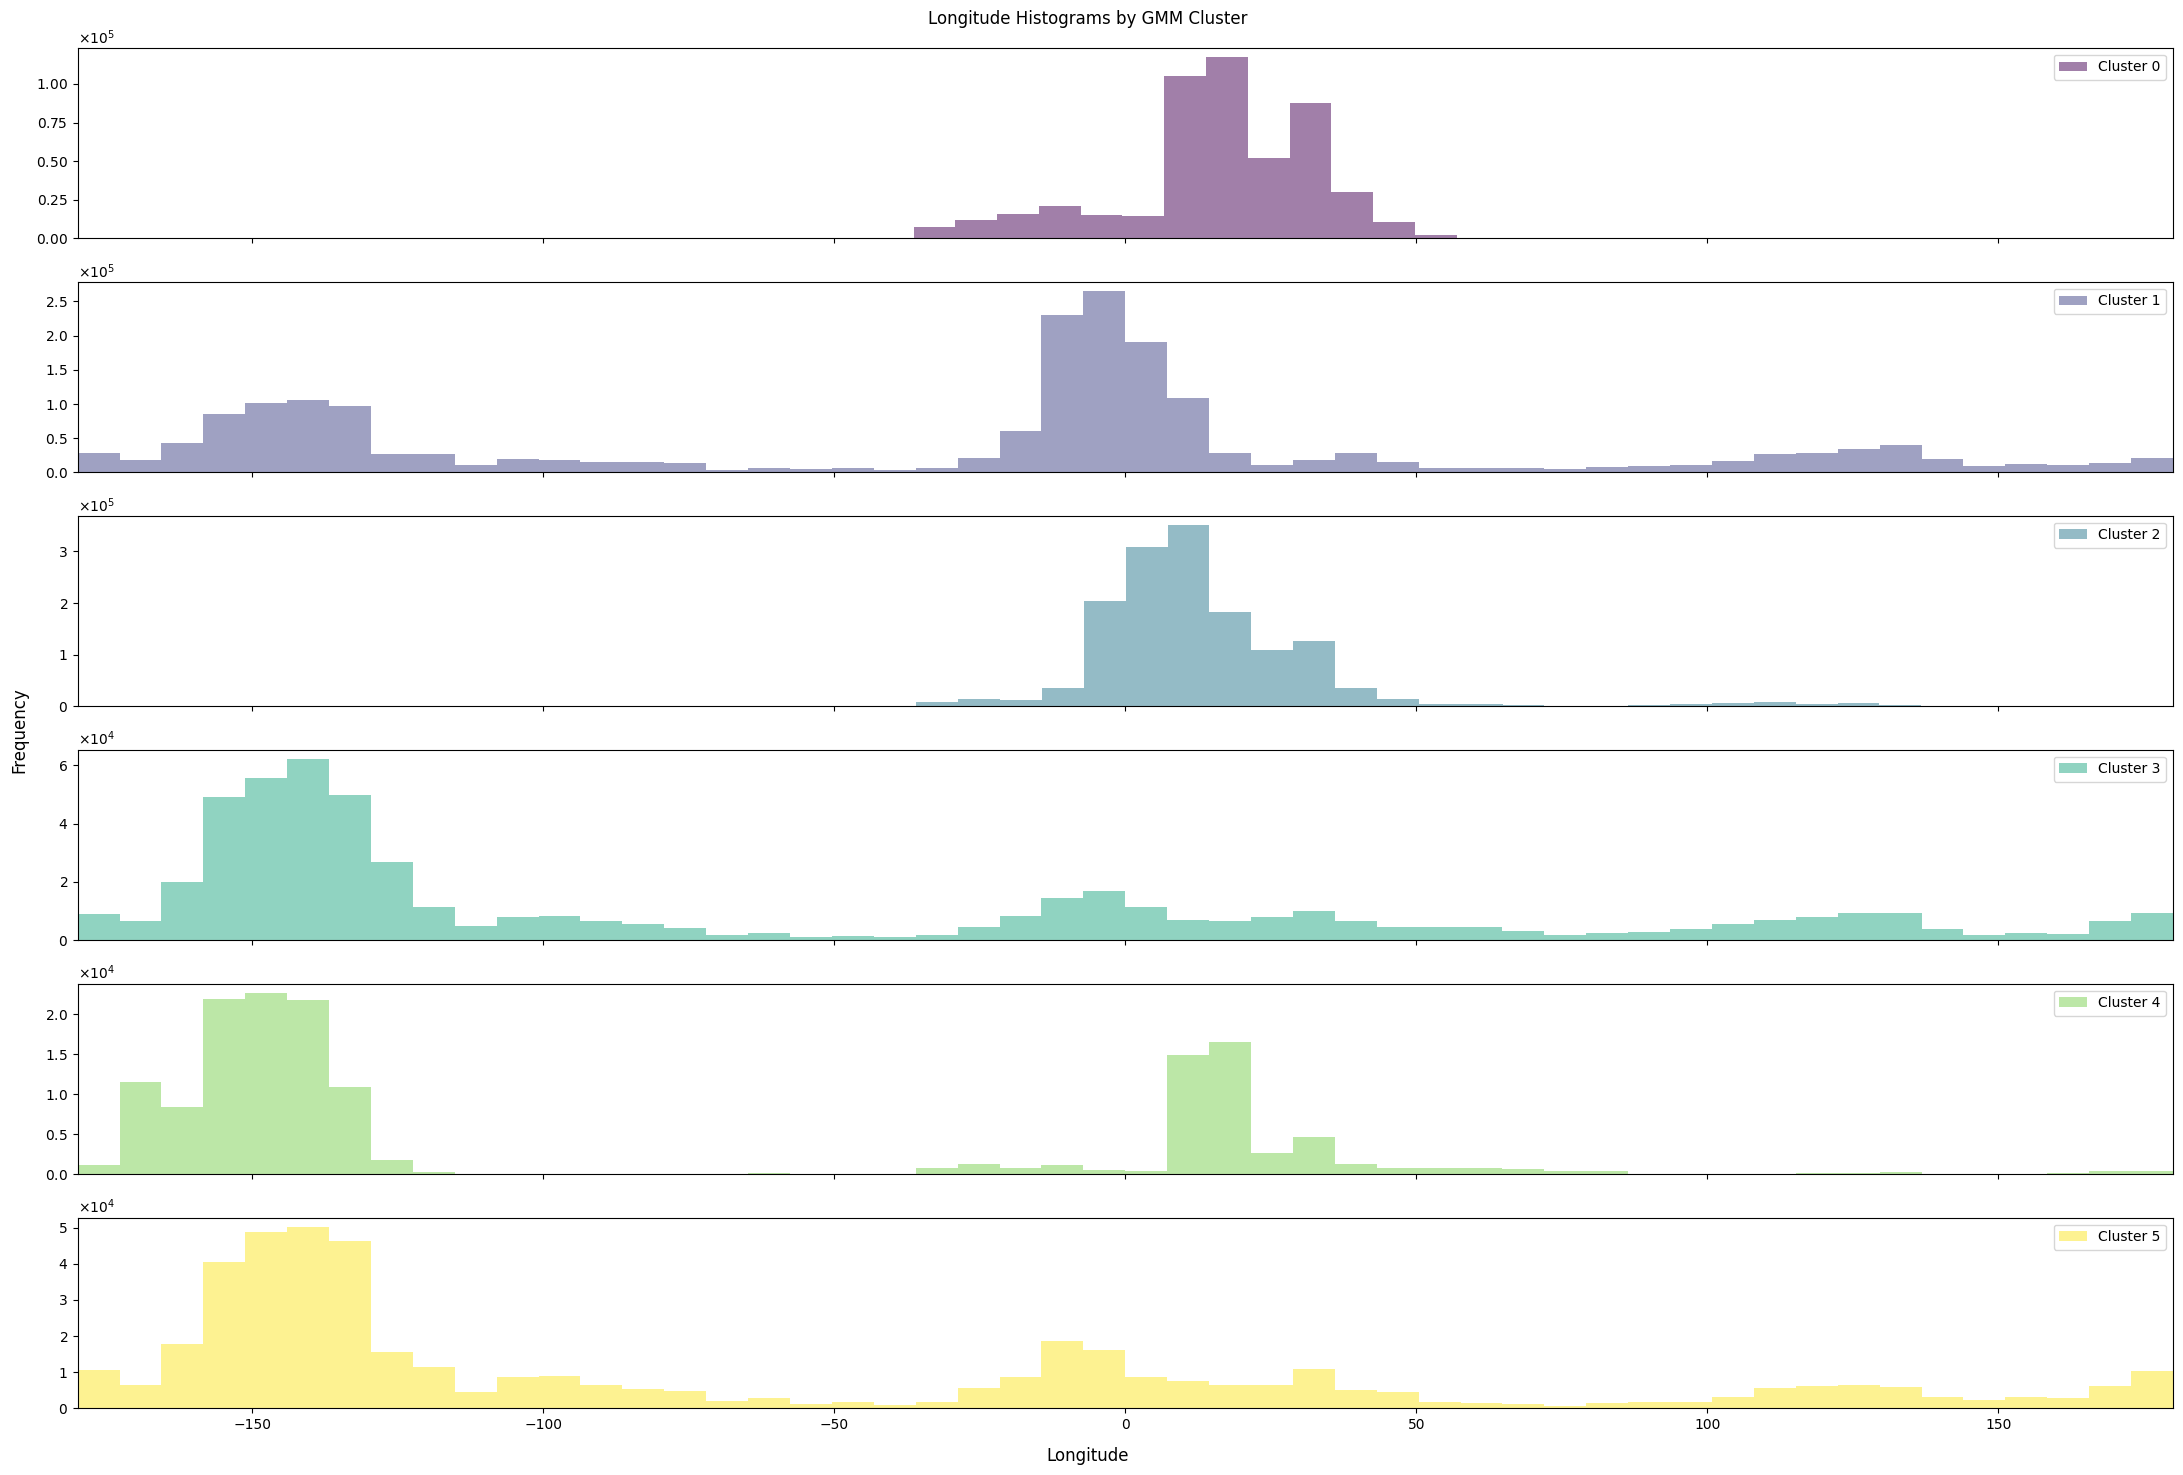

In [284]:
feature_histograms(df_sampled, feat_col='Longitude_[deg_E]', label_col='gmm_label_6', feature='Longitude')

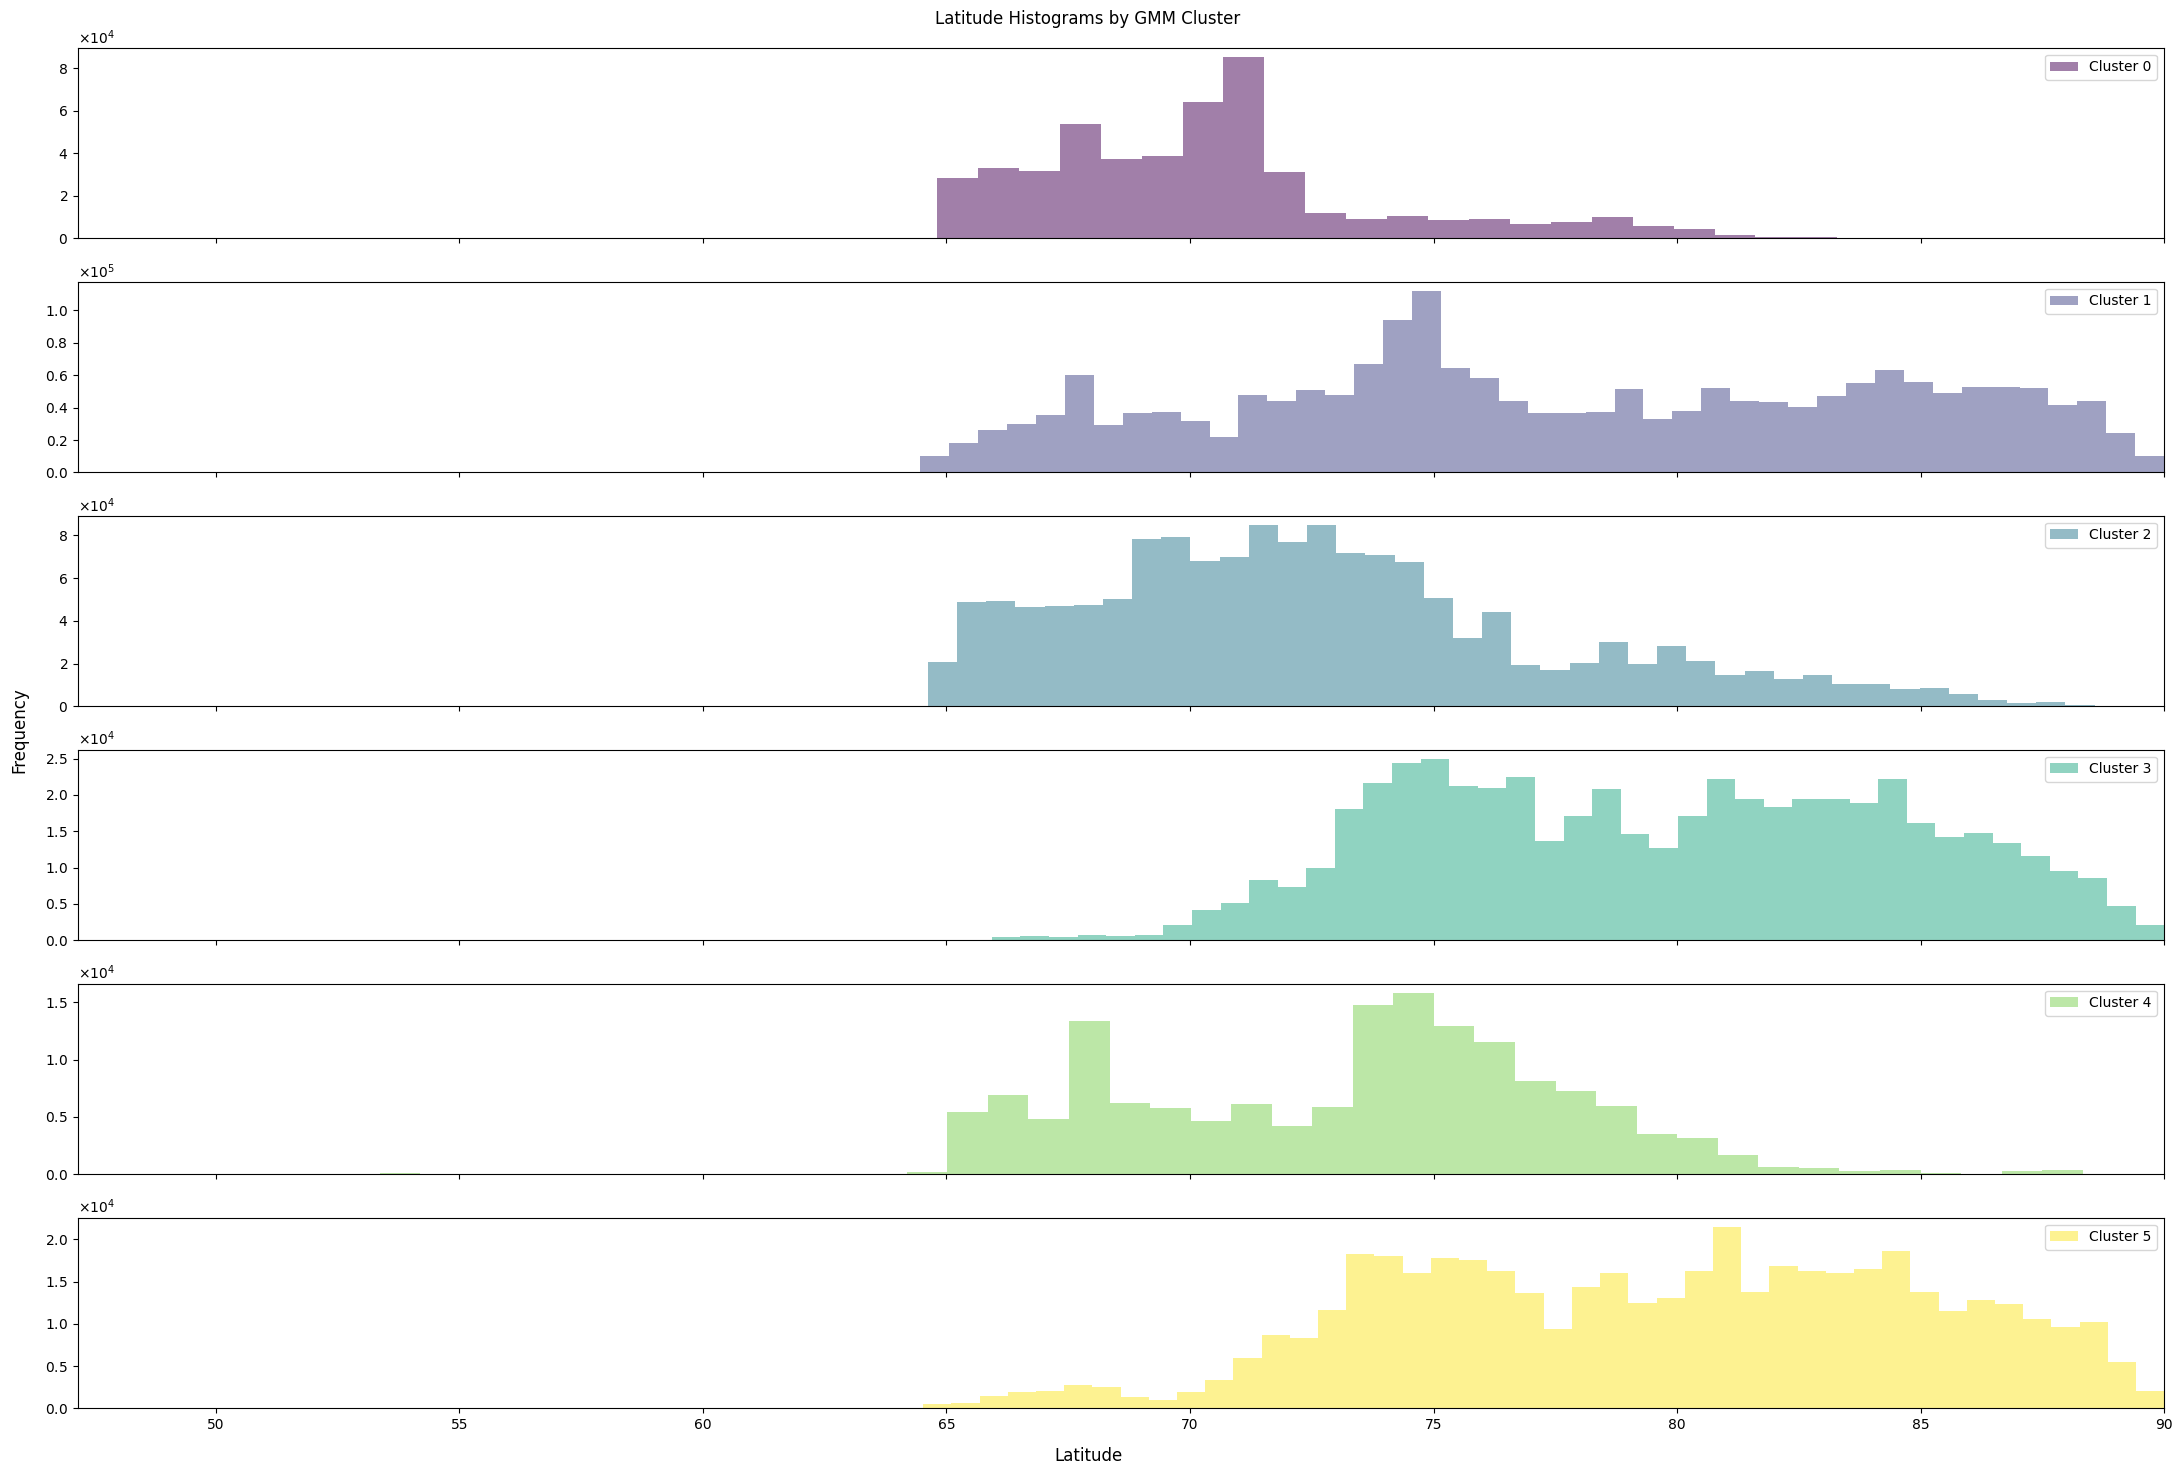

In [285]:
feature_histograms(df_sampled, feat_col='Latitude_[deg_N]', label_col='gmm_label_6', feature='Latitude')

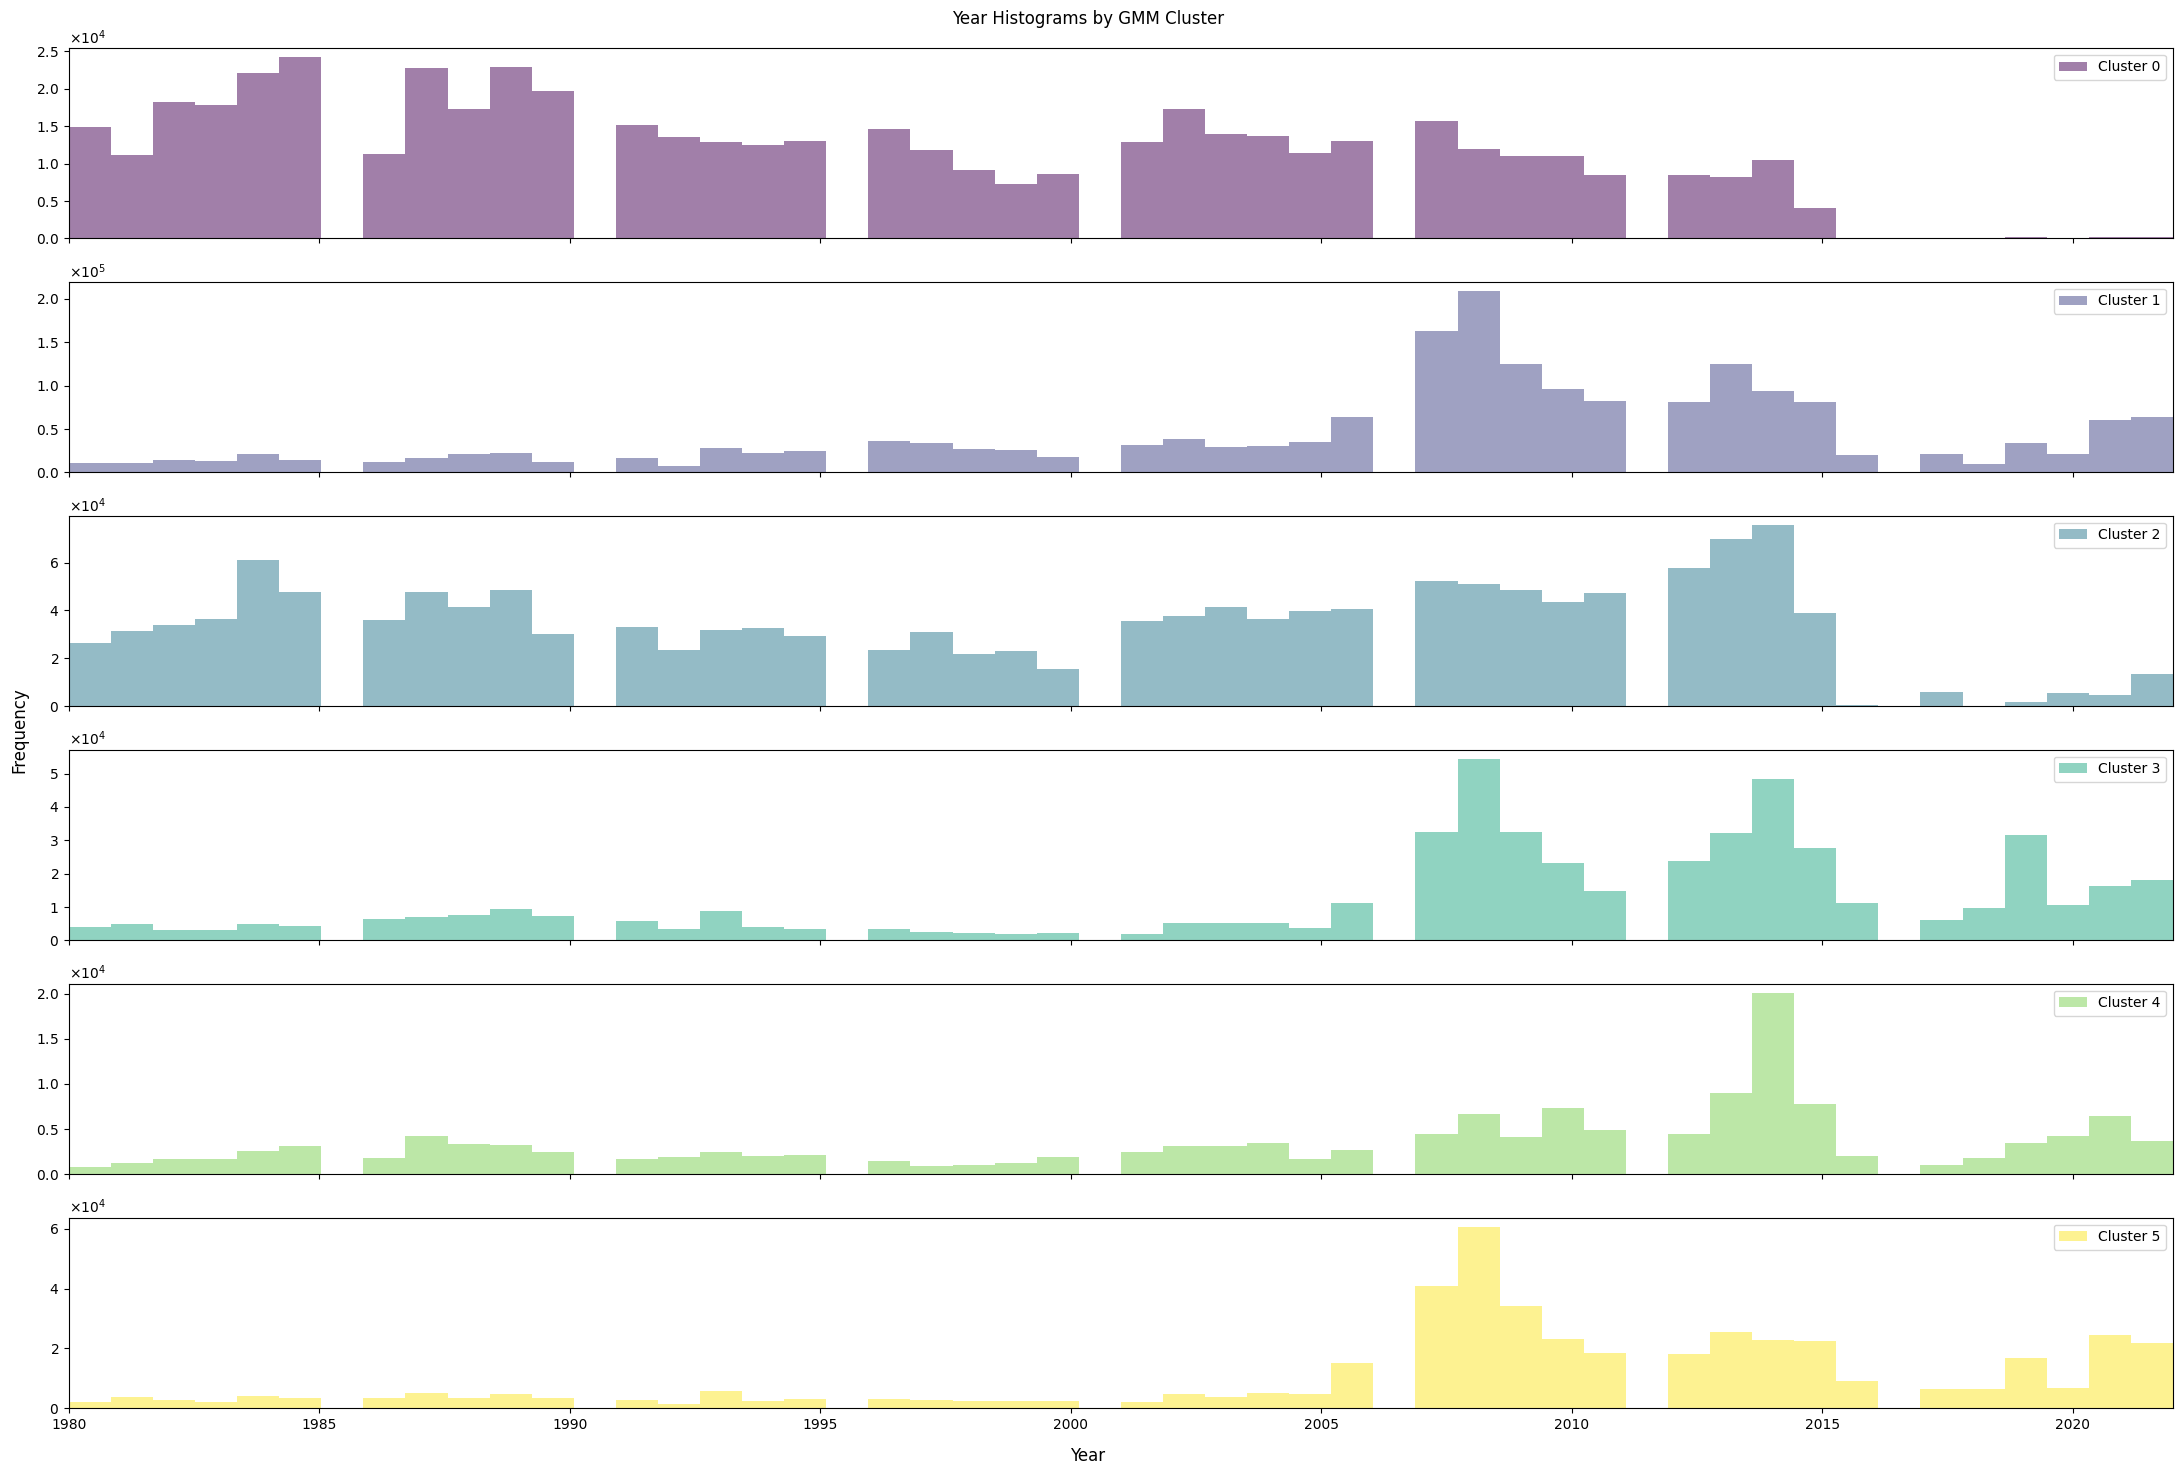

In [286]:
feature_histograms(df_sampled, feat_col='year', label_col='gmm_label_6', feature='Year')

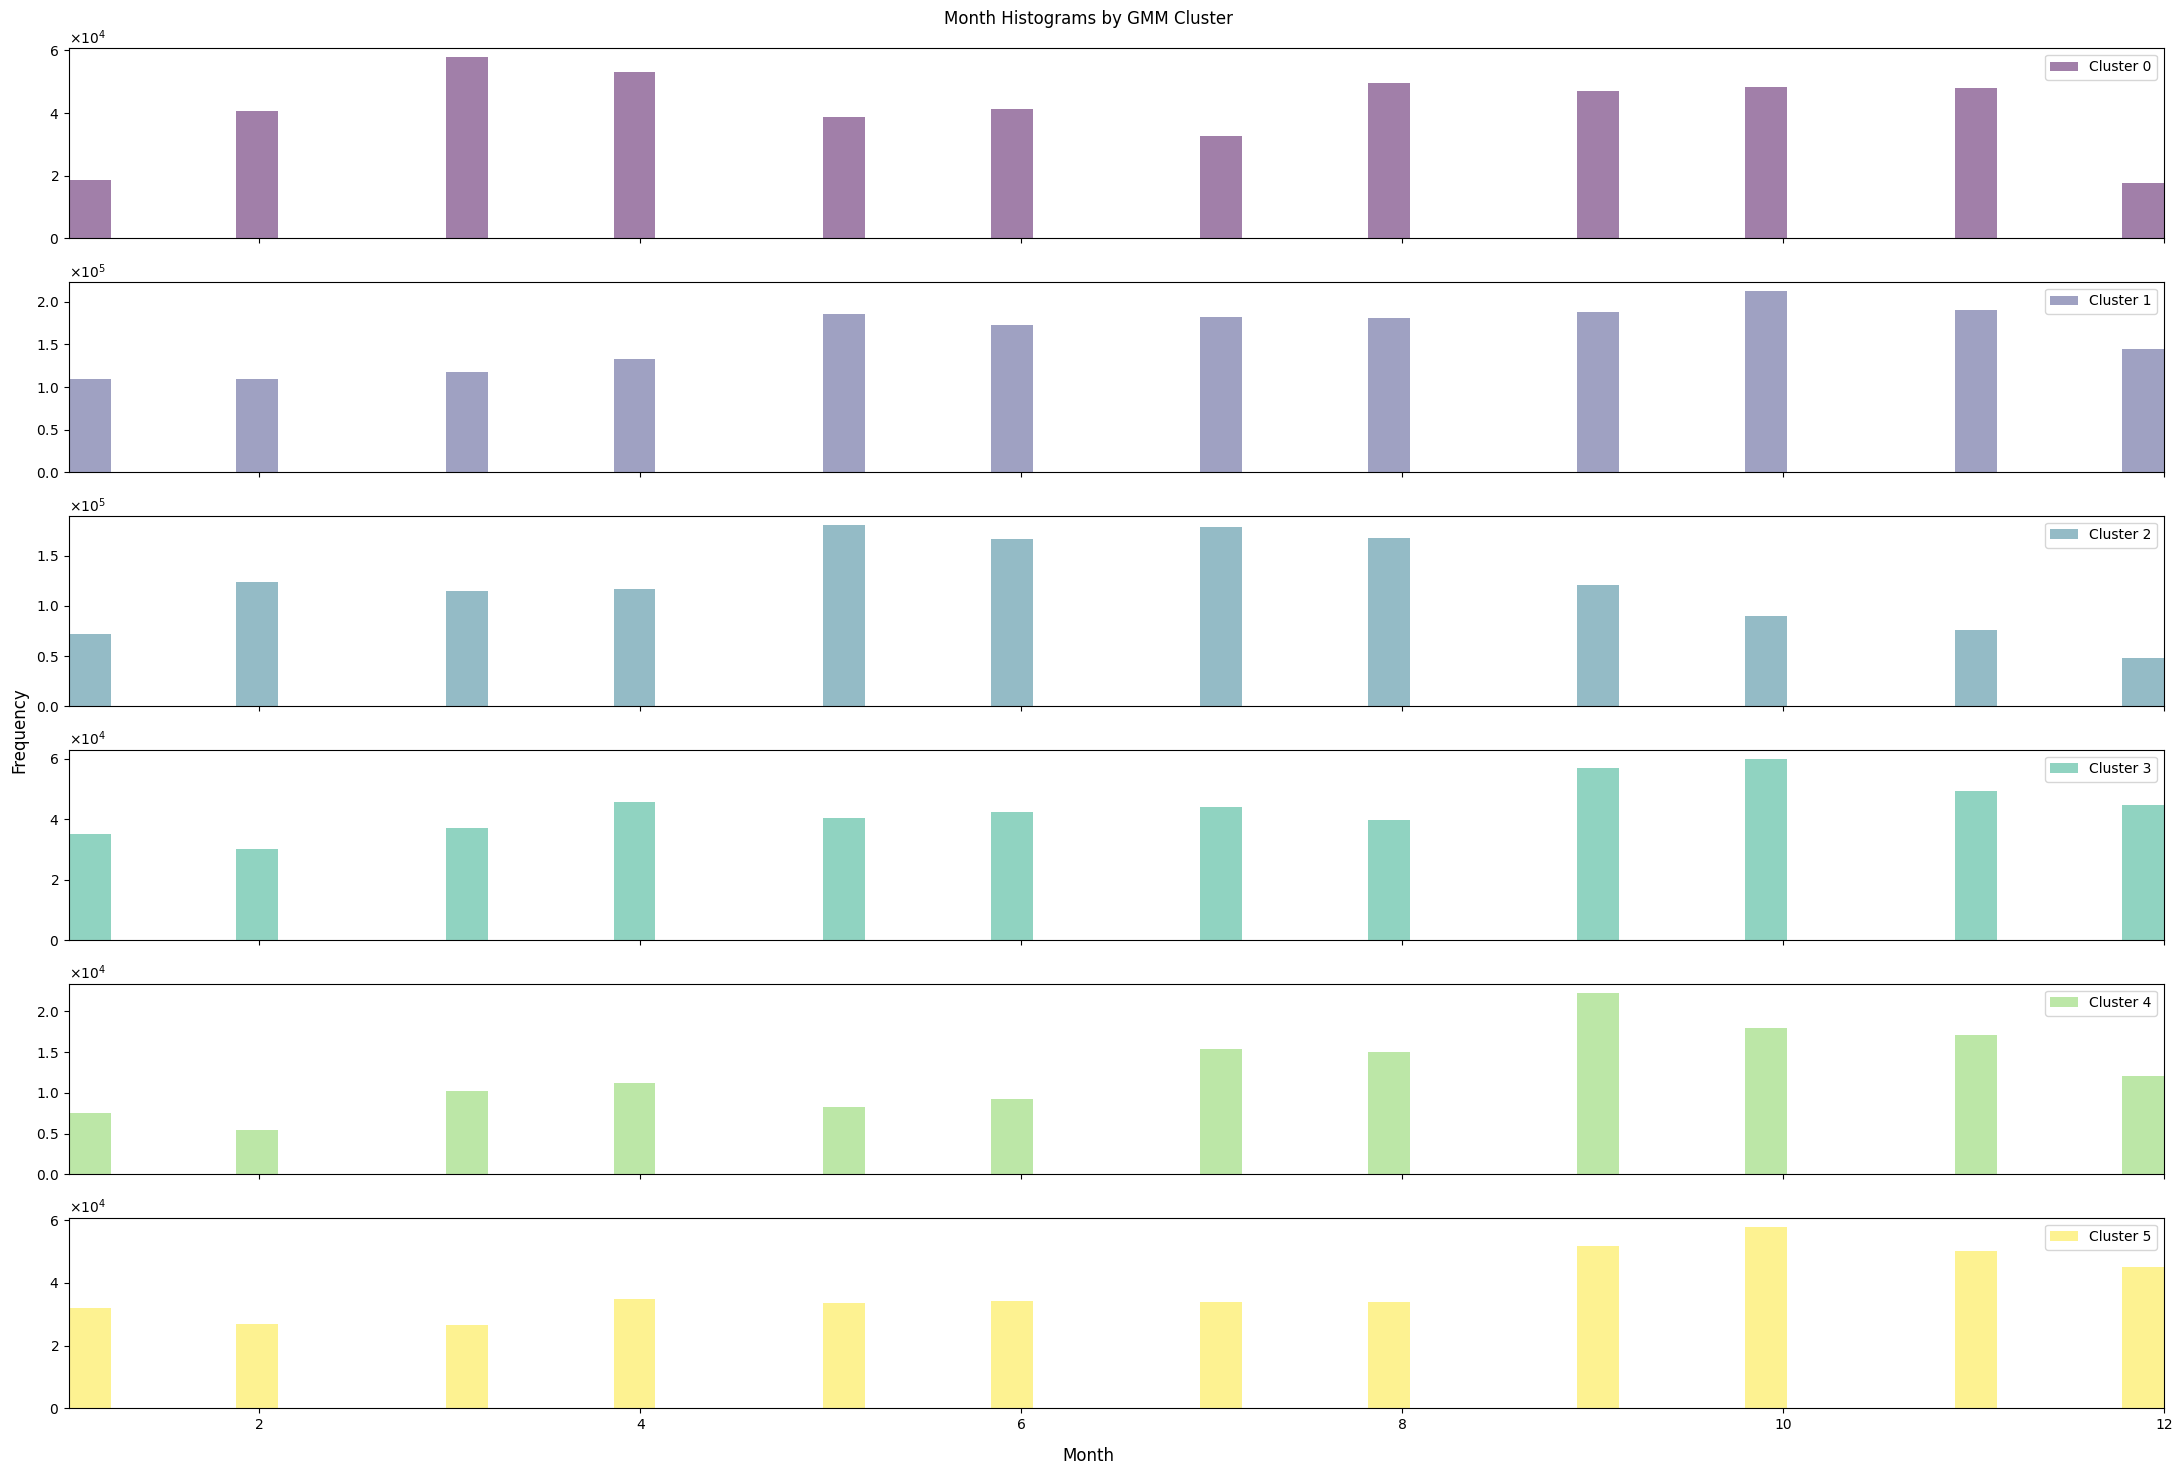

In [287]:
feature_histograms(df_sampled, feat_col='month', label_col='gmm_label_6', feature='Month')

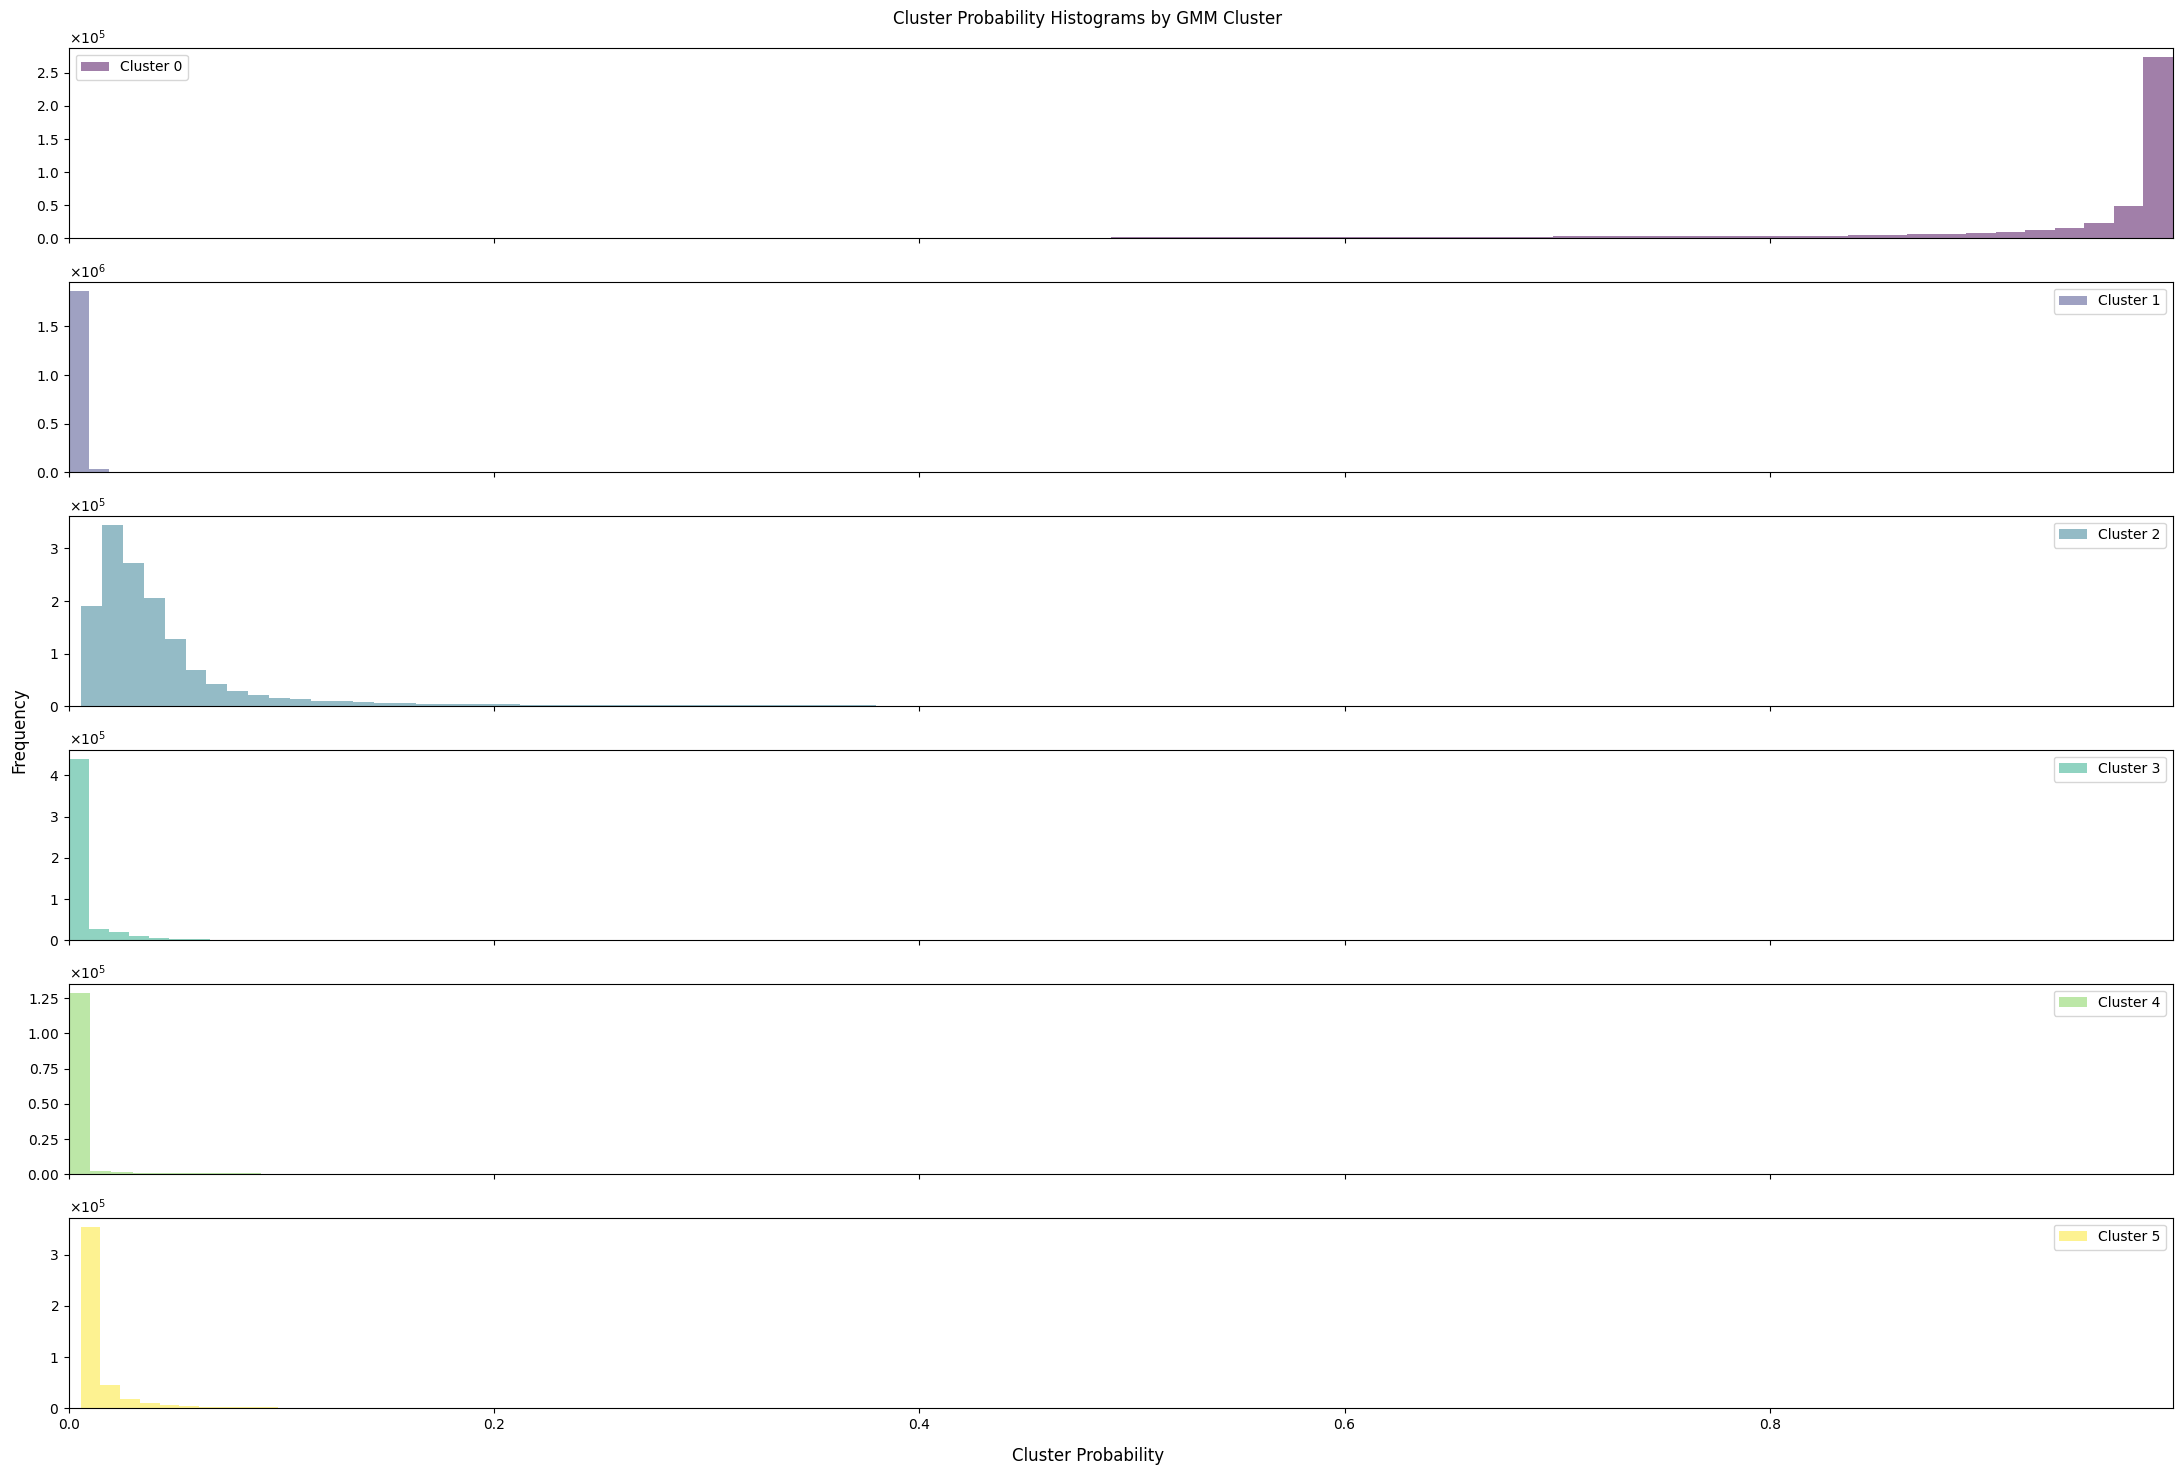

In [297]:
feature_histograms(df_sampled, feat_col='prob_cluster_4', label_col='gmm_label_6', feature='Cluster Probability')

In [302]:
for i in range(n_clusters):
    df_cluster = df_sampled[df_sampled['gmm_label_6'] == i]
    prob_metric = df_cluster['prob_cluster_'+str(i)].mean() / df_cluster['prob_cluster_'+str(i)].std()
    print(f'Cluster {i} Probability Metric: {prob_metric:.2f}')

Cluster 0 Probability Metric: 0.07
Cluster 1 Probability Metric: 0.86
Cluster 2 Probability Metric: 0.27
Cluster 3 Probability Metric: 0.38
Cluster 4 Probability Metric: 0.32
Cluster 5 Probability Metric: 6.21


In [303]:
for i in range(n_clusters):
    df_cluster = df_sampled[df_sampled['gmm_label_6'] == i]
    prob_metric = df_cluster['prob_cluster_'+str(i)].mean()
    print(f'Cluster {i} Probability Mean: {prob_metric:.2f}')

Cluster 0 Probability Mean: 0.00
Cluster 1 Probability Mean: 0.06
Cluster 2 Probability Mean: 0.02
Cluster 3 Probability Mean: 0.03
Cluster 4 Probability Mean: 0.03
Cluster 5 Probability Mean: 0.91


In [304]:
for i in range(n_clusters):
    df_cluster = df_sampled[df_sampled['gmm_label_6'] == i]
    prob_metric = df_cluster['prob_cluster_'+str(i)].std()
    print(f'Cluster {i} Probability Std Dev: {prob_metric:.2f}')

Cluster 0 Probability Std Dev: 0.02
Cluster 1 Probability Std Dev: 0.07
Cluster 2 Probability Std Dev: 0.07
Cluster 3 Probability Std Dev: 0.07
Cluster 4 Probability Std Dev: 0.09
Cluster 5 Probability Std Dev: 0.15


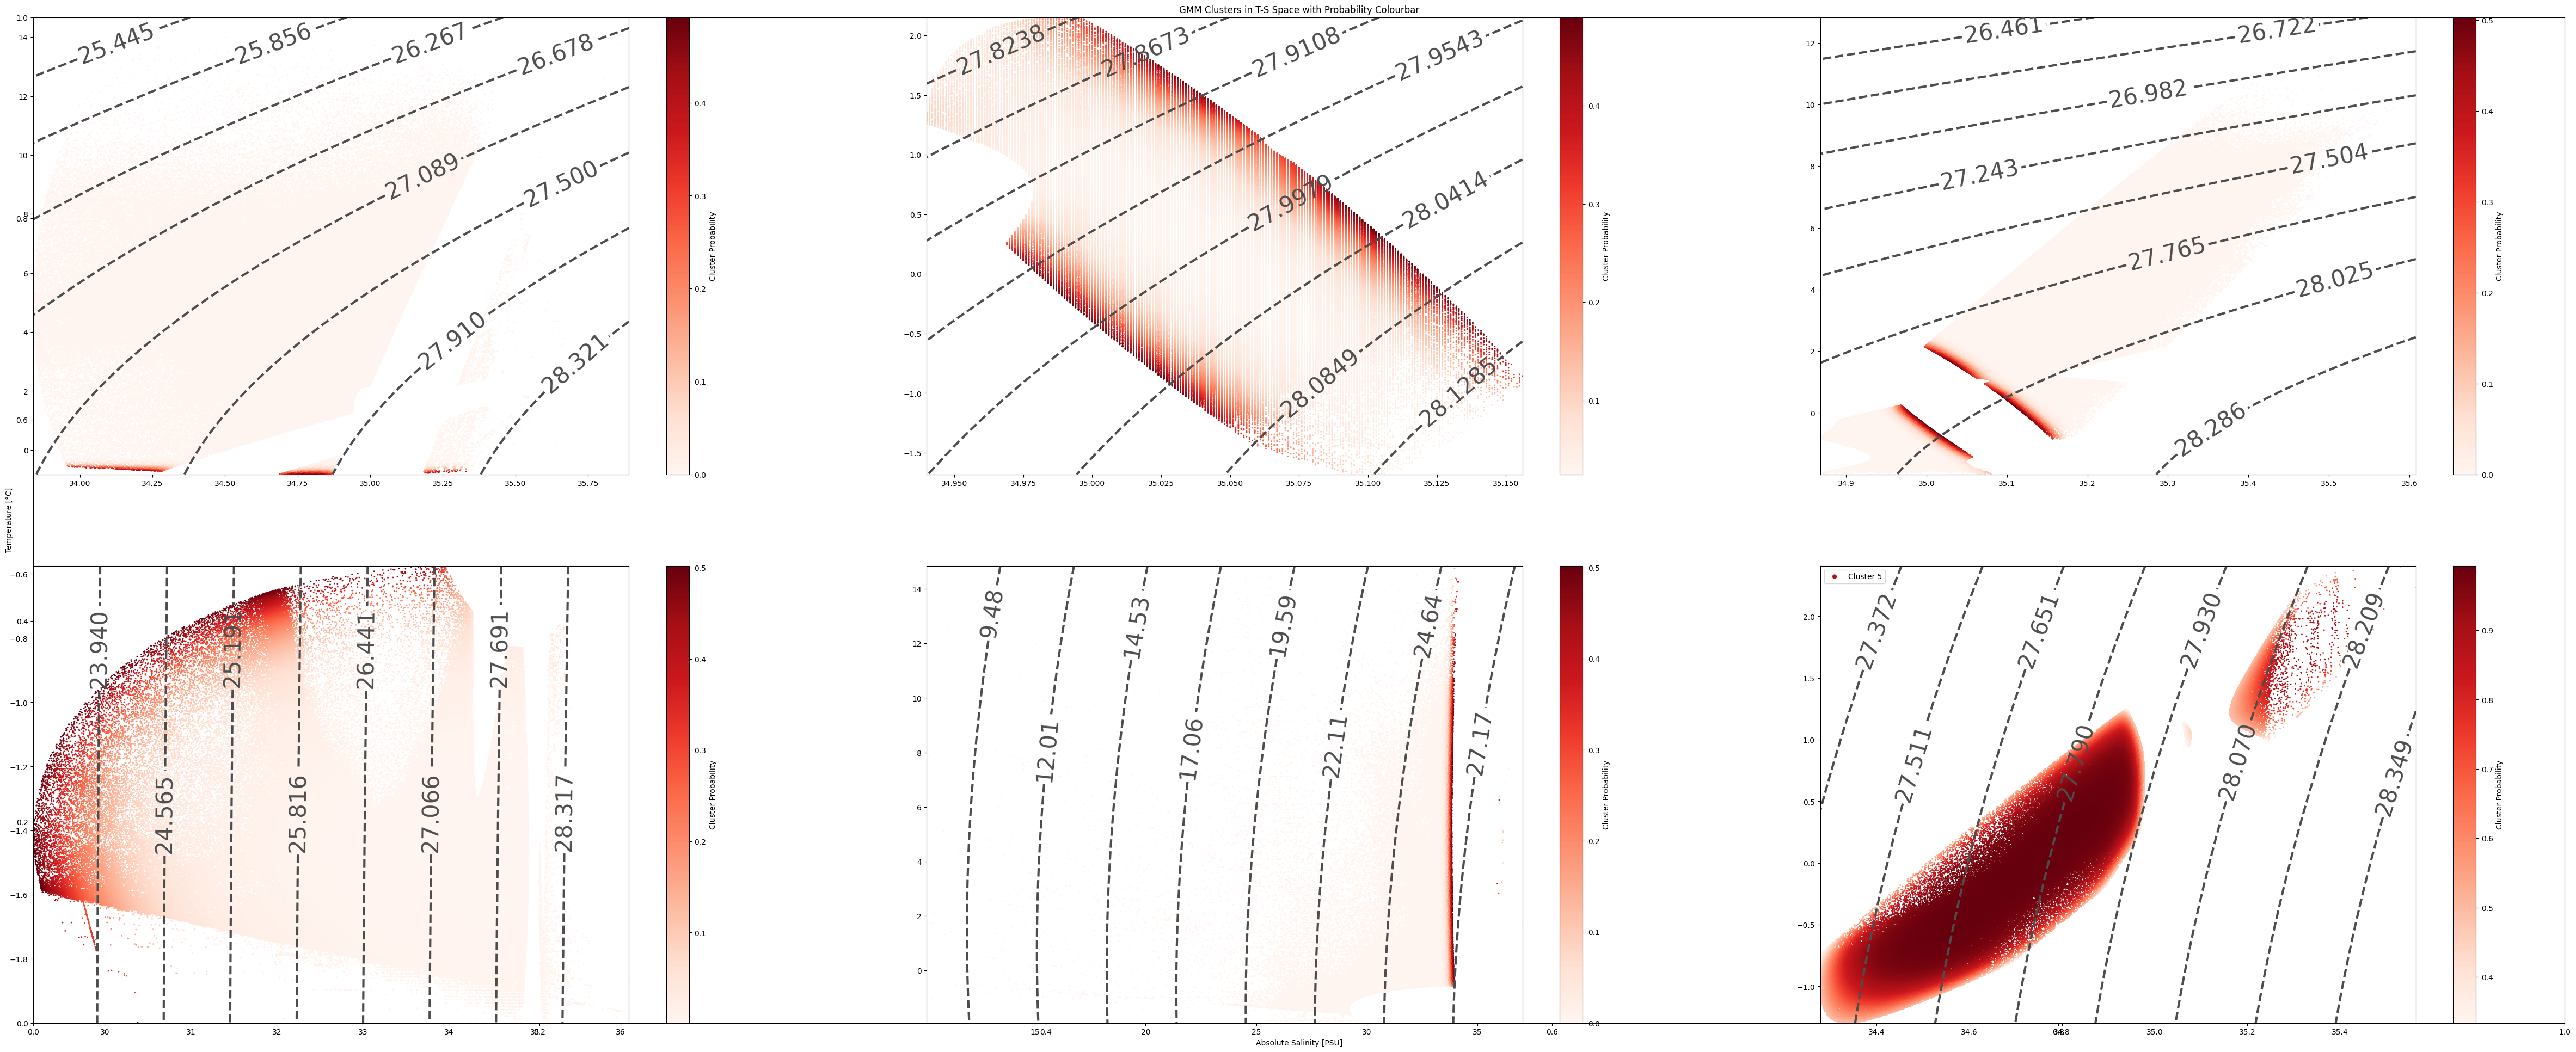

In [328]:
# Plot in TS space for each cluster amd its probability clourbar
plt.figure(figsize=(60, 24))
plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space with Probability Colourbar")
for i in range(n_clusters):
    plt.subplot(2, 3, i+1)
    mask = df_sampled['gmm_label_6'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=1,
        label=f'Cluster {i}',
        c=df_sampled.loc[mask, 'prob_cluster_'+str(i)],
        cmap='Reds')
    plt.colorbar(label='Cluster Probability')
    SA, CT = np.meshgrid(np.linspace(df_sampled.loc[mask,'Absolute_Salinity_[PSU]'].min(), df_sampled.loc[mask,'Absolute_Salinity_[PSU]'].max(), 400), np.linspace(df_sampled.loc[mask,'Conservative_Temperature_[deg_C]'].min(), df_sampled.loc[mask,'Conservative_Temperature_[deg_C]'].max(), 400))
    sigma0 = gsw.sigma0(SA, CT)
    levels = np.linspace(np.min(sigma0), np.max(sigma0), 10)
    contour = plt.contour(
        SA, CT, sigma0, levels=levels, 
        linestyles='--', colors='#4d4d4d', linewidths=3
    )
    plt.clabel(contour, inline=True, fontsize=30)
plt.legend(loc='upper left', markerscale=5)
plt.show()

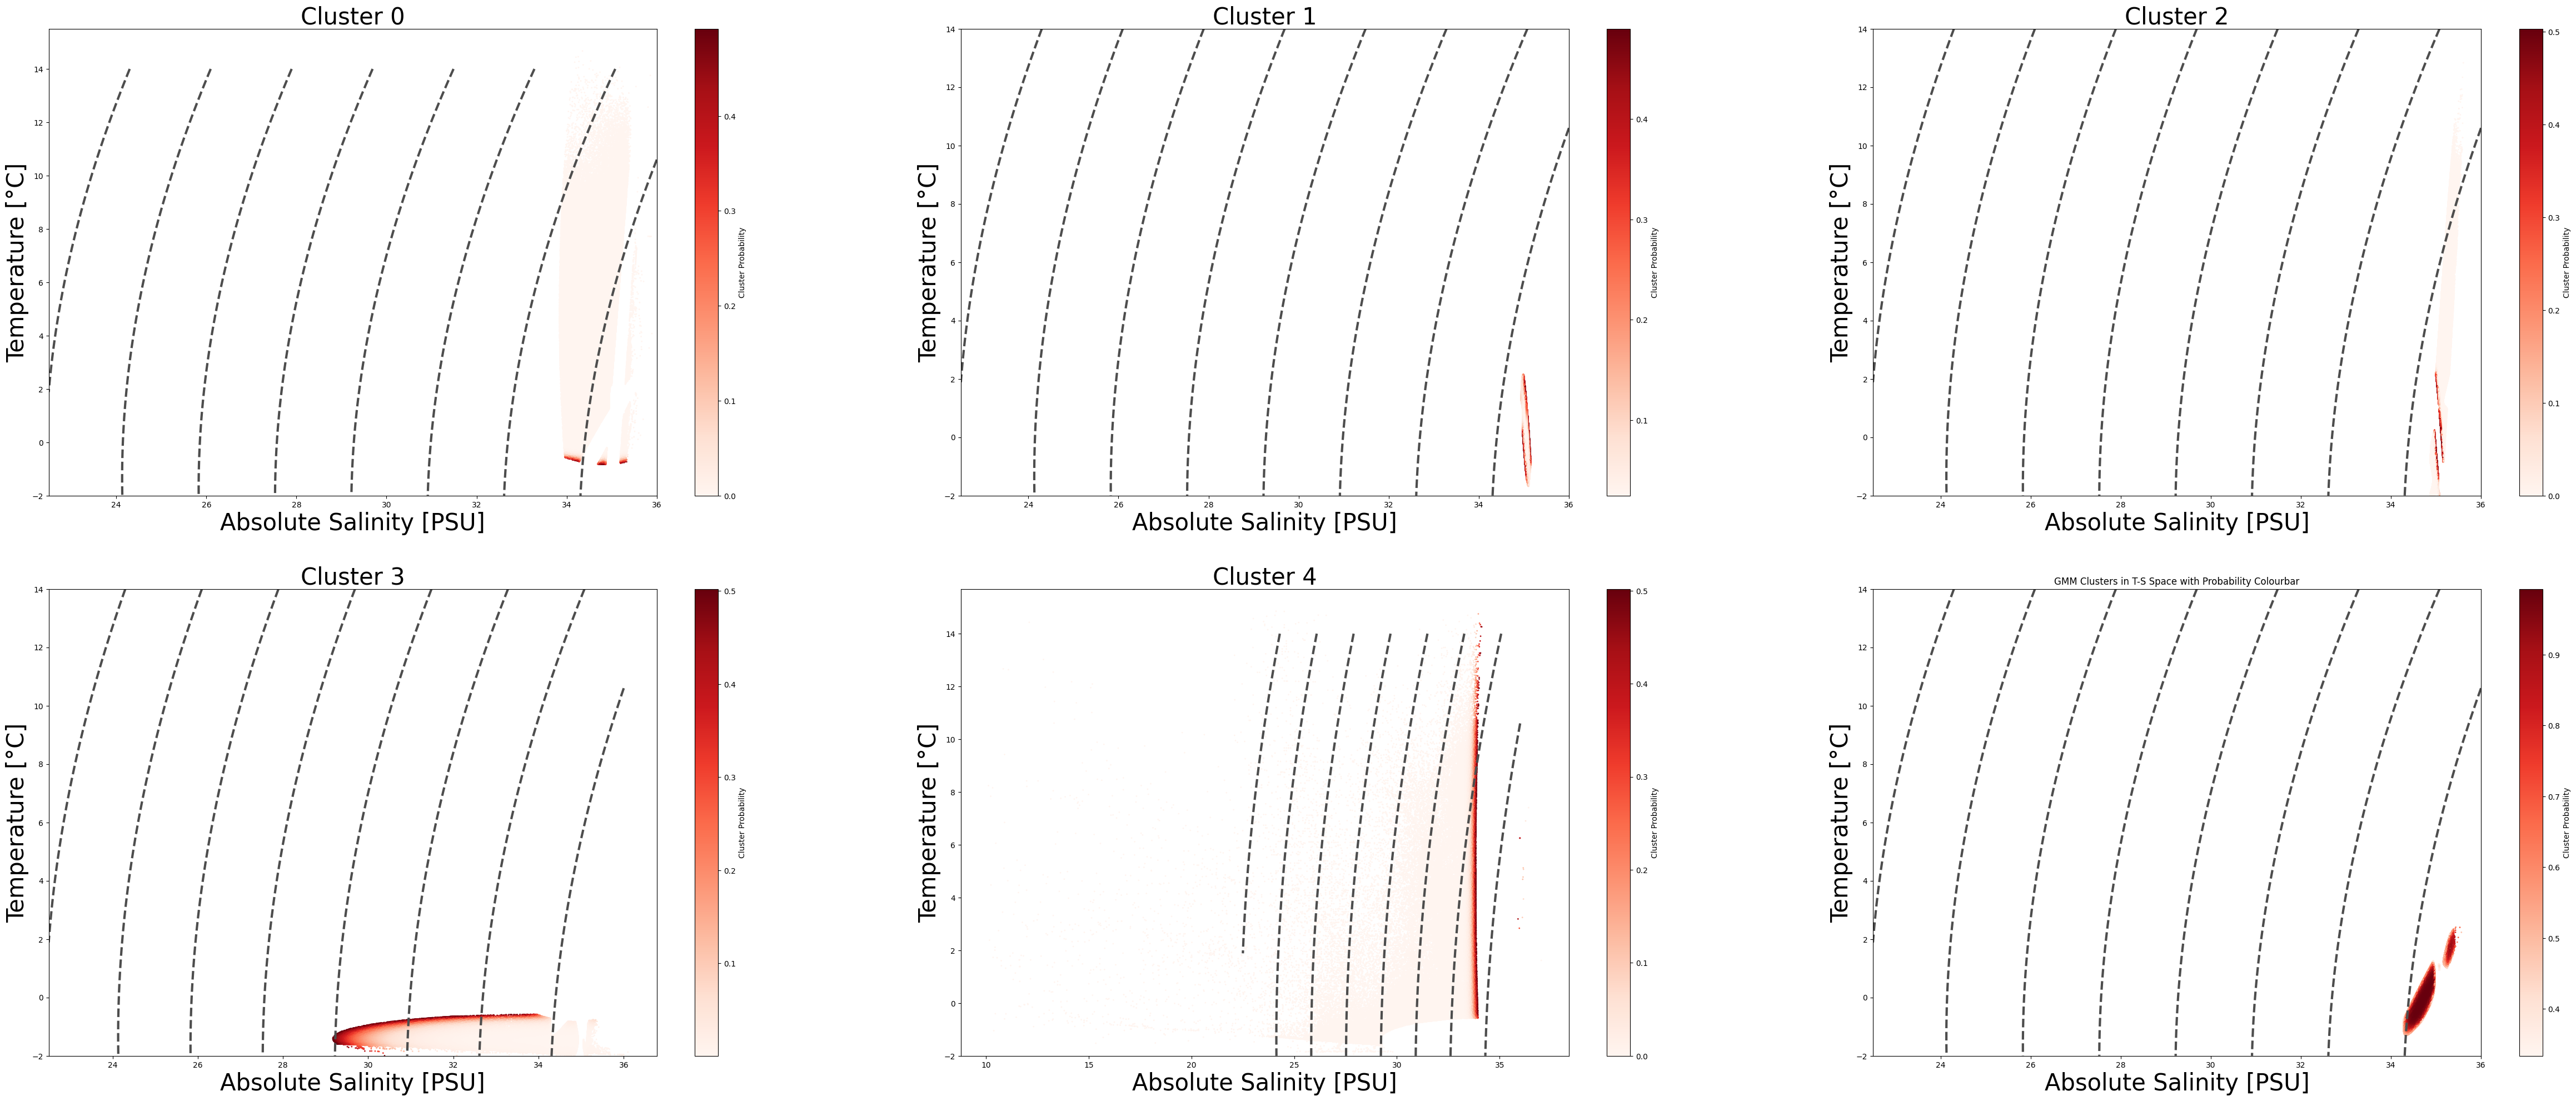

In [337]:
# Plot in TS space for each cluster amd its probability clourbar
plt.figure(figsize=(60, 24))
for i in range(n_clusters):
    plt.subplot(2, 3, i+1)
    mask = df_sampled['gmm_label_6'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=1,
        label=f'Cluster {i}',
        c=df_sampled.loc[mask, 'prob_cluster_'+str(i)],
        cmap='Reds')
    plt.title(f'Cluster {i}', fontsize=30)
    plt.colorbar(label='Cluster Probability')
    plt.xlabel("Absolute Salinity [PSU]", fontsize=30)
    plt.ylabel("Temperature [°C]", fontsize=30)
    SA, CT = np.meshgrid(np.linspace(22.5, 36, 400), np.linspace(-2, 14, 400))
    sigma0 = gsw.sigma0(SA, CT)
    levels = np.linspace(np.min(sigma0), np.max(sigma0), 10)
    contour = plt.contour(
        SA, CT, sigma0, levels=levels, 
        linestyles='--', colors='#4d4d4d', linewidths=3
    )
    #plt.clabel(contour, inline=True, fontsize=30)
plt.title("GMM Clusters in T-S Space with Probability Colourbar")
plt.show()